Make sure the following files are uploaded:
- SPX_Last_Open_val.xlsx, SPX_Volume.xlsx
- VIX_Index.xlsx
- USGG10YR.xlsx, USGG2YR.xlsx, USGG3M.xlsx
- XAUUSD_Last.xlsx
- DowJones_Last_Open.xlsx, DowJones_High_Low.xlsx
- Nasdaq_Last_Open.xlsx, Nasdaq_High_Low.xlsx
- MXWO_Last_Open_val.xlsx, MXWO_High_Low_val.xlsx
- ES1.xlsx, ES2.xlsx
- CL1_Comodity.xlsx, CO1_Comodity.xlsx

(Total 17 files)

*Note: Uploaded files in Colab will be deleted after the current runtime is disconnected. Make sure to upload the files every time in a new runtime.*





Raw Datasets:
https://1drv.ms/f/c/5f891edd5d6431fe/IgBV1riYSk-4RpBZQV4P9nHqAdjmubfDsGcAKRGhPFW7SCE?e=7iItV7

#Data Cleaning

In [ ]:
import pandas as pd
import numpy as np

###1. Helper Function

In [ ]:
def read_bloomberg_excel(path):
    """
    Reads a Bloomberg-exported Excel file by automatically
    finding the header row that starts with 'Date'.
    """
    raw = pd.read_excel(path, header=None)

    # Find the row where the first column is 'Date'
    header_row = raw.index[raw.iloc[:, 0].astype(str).str.strip().eq("Date")][0]

    df = pd.read_excel(path, header=header_row)

    # Remove unnamed empty columns
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed")]

    return df

###2. Read the 4 datasets

In [ ]:
# --- SPX (split into OHLC + Volume) ---
spx_ohlc = read_bloomberg_excel("SPX Last Open val.xlsx")
spx_vol  = read_bloomberg_excel("SPX Volume.xlsx")

# --- VIX (HIGH and LOW) ---
vix = read_bloomberg_excel("VIX Index.xlsx")

# --- US Treasury Yields ---
us10y = read_bloomberg_excel("USGG10YR.xlsx")
us2y  = read_bloomberg_excel("USGG2YR.xlsx")
us3m  = read_bloomberg_excel("USGG3M.xlsx")

# --- Gold ---
gold = read_bloomberg_excel("XAUUSD Last.xlsx")

# --- Dow Jones (split into Last/Open + High/Low) ---
dj_lo = read_bloomberg_excel("DowJones Last Open.xlsx")
dj_hl = read_bloomberg_excel("DowJones High Low.xlsx")

# --- Nasdaq (split into Last/Open + High/Low) ---
ndx_lo = read_bloomberg_excel("Nasdaq Last Open.xlsx")
ndx_hl = read_bloomberg_excel("Nasdaq High Low.xlsx")

# --- MSCI World (split into Last/Open + High/Low) ---
mxwo_lo = read_bloomberg_excel("MXWO Last Open val.xlsx")
mxwo_hl = read_bloomberg_excel("MXWO High Low val.xlsx")

# --- E-mini S&P500 Futures (front and second contract) ---
es1 = read_bloomberg_excel("ES1.xlsx")
es2 = read_bloomberg_excel("ES2.xlsx")

# --- Crude Oil ---
cl1 = read_bloomberg_excel("CL1 Comodity.xlsx")   # WTI
co1 = read_bloomberg_excel("CO1 Comodity.xlsx")   # Brent

###3. Merge files internally on Date using SPX_OHLC as an anchor

In [ ]:
# SPX: merge OHLC + Volume
spx = spx_ohlc.merge(spx_vol[["Date", "PX_VOLUME"]], on="Date", how="inner")

# Dow Jones: merge Last/Open + High/Low
dj = dj_lo.merge(dj_hl, on="Date", how="inner")

# Nasdaq: merge Last/Open + High/Low
ndx = ndx_lo.merge(ndx_hl, on="Date", how="inner")

# MXWO: merge Last/Open + High/Low
mxwo = mxwo_lo.merge(mxwo_hl, on="Date", how="inner")

###4. Standardize Column Names

In [ ]:
spx = spx.rename(columns={
    "PX_LAST":   "SPX_PX_LAST",
    "PX_OPEN":   "SPX_PX_OPEN",
    "PX_HIGH":   "SPX_PX_HIGH",
    "PX_LOW":    "SPX_PX_LOW",
    "PX_VOLUME": "SPX_PX_VOLUME"
})

# Note: new VIX file has PX_HIGH and PX_LOW only — no PX_LAST
vix = vix.rename(columns={
    "PX_HIGH": "VIX_PX_HIGH",
    "PX_LOW":  "VIX_PX_LOW"
})

us10y = us10y.rename(columns={"PX_LAST": "USGG10YR_PX_LAST"})
us2y  = us2y.rename(columns={"PX_LAST":  "USGG2YR_PX_LAST"})
us3m  = us3m.rename(columns={"PX_LAST":  "USGG3M_PX_LAST"})

gold = gold.rename(columns={"PX_LAST": "XAUUSD_PX_LAST"})

dj = dj.rename(columns={
    "PX_LAST": "DJ_PX_LAST",
    "PX_OPEN": "DJ_PX_OPEN",
    "PX_HIGH": "DJ_PX_HIGH",
    "PX_LOW":  "DJ_PX_LOW"
})

ndx = ndx.rename(columns={
    "PX_LAST": "NDX_PX_LAST",
    "PX_OPEN": "NDX_PX_OPEN",
    "PX_HIGH": "NDX_PX_HIGH",
    "PX_LOW":  "NDX_PX_LOW"
})

mxwo = mxwo.rename(columns={
    "PX_LAST": "MXWO_PX_LAST",
    "PX_OPEN": "MXWO_PX_OPEN",
    "PX_HIGH": "MXWO_PX_HIGH",
    "PX_LOW":  "MXWO_PX_LOW"
})

es1 = es1.rename(columns={"PX_HIGH": "ES1_PX_HIGH", "PX_LOW": "ES1_PX_LOW"})
es2 = es2.rename(columns={"PX_HIGH": "ES2_PX_HIGH", "PX_LOW": "ES2_PX_LOW"})

cl1 = cl1.rename(columns={"PX_LAST": "CL1_PX_LAST"})   # WTI crude
co1 = co1.rename(columns={"PX_LAST": "CO1_PX_LAST"})   # Brent crude

###Keep only useful columns (Remove PX_BID)

In [ ]:
spx      = spx[["Date", "SPX_PX_LAST", "SPX_PX_OPEN", "SPX_PX_HIGH", "SPX_PX_LOW", "SPX_PX_VOLUME"]]
vix      = vix[["Date", "VIX_PX_HIGH", "VIX_PX_LOW"]]
us10y    = us10y[["Date", "USGG10YR_PX_LAST"]]
us2y     = us2y[["Date",  "USGG2YR_PX_LAST"]]
us3m     = us3m[["Date",  "USGG3M_PX_LAST"]]
gold     = gold[["Date",  "XAUUSD_PX_LAST"]]
dj       = dj[["Date",   "DJ_PX_LAST",   "DJ_PX_OPEN",   "DJ_PX_HIGH",   "DJ_PX_LOW"]]
ndx      = ndx[["Date",  "NDX_PX_LAST",  "NDX_PX_OPEN",  "NDX_PX_HIGH",  "NDX_PX_LOW"]]
mxwo     = mxwo[["Date", "MXWO_PX_LAST", "MXWO_PX_OPEN", "MXWO_PX_HIGH", "MXWO_PX_LOW"]]
es1      = es1[["Date",  "ES1_PX_HIGH",  "ES1_PX_LOW"]]
es2      = es2[["Date",  "ES2_PX_HIGH",  "ES2_PX_LOW"]]
cl1      = cl1[["Date",  "CL1_PX_LAST"]]
co1      = co1[["Date",  "CO1_PX_LAST"]]

###5. Ensure Date is datetime

In [ ]:
for df_temp in [spx, vix, us10y, us2y, us3m, gold, dj, ndx, mxwo, es1, es2, cl1, co1]:
    df_temp["Date"] = pd.to_datetime(df_temp["Date"])

###6. Sort ascending by date

In [ ]:
for df_temp in [spx, vix, us10y, us2y, us3m, gold, dj, ndx, mxwo, es1, es2, cl1, co1]:
    df_temp.sort_values("Date", inplace=True)
    df_temp.reset_index(drop=True, inplace=True)

###7. Merge everything onto SPX dates

In [ ]:
# Use SPX as the master calendar (left join preserves SPX trading days)
df = spx.copy()
for aux in [vix, us10y, us2y, us3m, gold, dj, ndx, mxwo, es1, es2, cl1, co1]:
    df = df.merge(aux, on="Date", how="left")

###8. Handle missing values properly

In [ ]:
aux_cols = [
    "VIX_PX_HIGH", "VIX_PX_LOW",
    "USGG10YR_PX_LAST", "USGG2YR_PX_LAST", "USGG3M_PX_LAST",
    "XAUUSD_PX_LAST",
    "DJ_PX_LAST", "DJ_PX_OPEN", "DJ_PX_HIGH", "DJ_PX_LOW",
    "NDX_PX_LAST", "NDX_PX_OPEN", "NDX_PX_HIGH", "NDX_PX_LOW",
    "MXWO_PX_LAST", "MXWO_PX_OPEN", "MXWO_PX_HIGH", "MXWO_PX_LOW",
    "ES1_PX_HIGH", "ES1_PX_LOW",
    "ES2_PX_HIGH", "ES2_PX_LOW",
    "CL1_PX_LAST", "CO1_PX_LAST"
]

# Forward-fill for market holidays / non-trading days
df[aux_cols] = df[aux_cols].ffill()

# Back-fill only for leading NaNs (VIX backfilled from Jan 1992)
df[aux_cols] = df[aux_cols].bfill()

###9. Final sanity checks

In [ ]:
print("Shape after merge:", df.shape)
print("\nMissing values by column:")
print(df.isnull().sum())

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nPreview:")
print(df.head())

Shape after merge: (9067, 30)

Missing values by column:
Date                0
SPX_PX_LAST         0
SPX_PX_OPEN         0
SPX_PX_HIGH         0
SPX_PX_LOW          0
SPX_PX_VOLUME       0
VIX_PX_HIGH         0
VIX_PX_LOW          0
USGG10YR_PX_LAST    0
USGG2YR_PX_LAST     0
USGG3M_PX_LAST      0
XAUUSD_PX_LAST      0
DJ_PX_LAST          0
DJ_PX_OPEN          0
DJ_PX_HIGH          0
DJ_PX_LOW           0
NDX_PX_LAST         0
NDX_PX_OPEN         0
NDX_PX_HIGH         0
NDX_PX_LOW          0
MXWO_PX_LAST        0
MXWO_PX_OPEN        0
MXWO_PX_HIGH        0
MXWO_PX_LOW         0
ES1_PX_HIGH         0
ES1_PX_LOW          0
ES2_PX_HIGH         0
ES2_PX_LOW          0
CL1_PX_LAST         0
CO1_PX_LAST         0
dtype: int64

Date range:
1990-04-02 00:00:00 to 2026-04-02 00:00:00

Preview:
        Date  SPX_PX_LAST  SPX_PX_OPEN  SPX_PX_HIGH  SPX_PX_LOW  \
0 1990-04-02       338.70       339.94       339.94      336.33   
1 1990-04-03       343.64       338.70       343.76      338.70   
2 1

###10. Save cleaned dataset

In [ ]:
df.to_csv("cleaned_bloomberg_merged.csv", index=False)

# Optional: also save as Excel
df.to_excel("cleaned_bloomberg_merged.xlsx", index=False)

print("\nFiles saved:")
print("- cleaned_bloomberg_merged.csv")
print("- cleaned_bloomberg_merged.xlsx")


Files saved:
- cleaned_bloomberg_merged.csv
- cleaned_bloomberg_merged.xlsx


#Feature Engineering

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Helper functions

def garman_klass_vol(open_, high, low, close, window):
    """
    Garman-Klass volatility estimator — up to 8x more efficient than
    close-to-close. Requires OHLC data.
    """
    log_hl = (np.log(high / low)) ** 2
    log_co = (np.log(close / open_)) ** 2
    gk = 0.5 * log_hl - (2 * np.log(2) - 1) * log_co
    return gk.rolling(window).mean().apply(np.sqrt) * np.sqrt(252)

def compute_rsi(series, window):
    """RSI — Relative Strength Index."""
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    # Use epsilon instead of NaN — when loss=0, RSI correctly returns 100 (all gains)
    rs    = gain / loss.replace(0, 1e-10)
    return 100 - (100 / (1 + rs))

def rolling_sharpe(log_returns, window):
    """Annualised rolling Sharpe ratio (no risk-free rate)."""
    mu  = log_returns.rolling(window).mean() * 252
    sig = log_returns.rolling(window).std()  * np.sqrt(252)
    return mu / sig.replace(0, np.nan)

def rolling_zscore(series, window=252):
    """Rolling z-score — avoids look-ahead bias from global normalisation."""
    mu  = series.rolling(window).mean()
    sig = series.rolling(window).std()
    return (series - mu) / sig.replace(0, np.nan)

###1. Load cleaned dataset

In [ ]:
df = pd.read_csv("cleaned_bloomberg_merged.csv")

# Convert Date to datetime and sort
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

###2. Feature engineering

####SPX price, returns & volatility

In [ ]:
# ── TIER 1A: Log returns at exponentially-spaced windows ────────────────────
df["SPX_log_ret_1d"]  = np.log(df["SPX_PX_LAST"] / df["SPX_PX_LAST"].shift(1))
df["SPX_log_ret_5d"]  = np.log(df["SPX_PX_LAST"] / df["SPX_PX_LAST"].shift(5))
df["SPX_log_ret_21d"] = np.log(df["SPX_PX_LAST"] / df["SPX_PX_LAST"].shift(21))
df["SPX_log_ret_63d"] = np.log(df["SPX_PX_LAST"] / df["SPX_PX_LAST"].shift(63))
df["SPX_log_ret_126d"]= np.log(df["SPX_PX_LAST"] / df["SPX_PX_LAST"].shift(126))

# ── TIER 1B: Garman-Klass volatility (OHLC available for SPX) ───────────────
for w in [5, 10, 21, 63]:
    df[f"SPX_GK_vol_{w}d"] = garman_klass_vol(
        df["SPX_PX_OPEN"], df["SPX_PX_HIGH"],
        df["SPX_PX_LOW"],  df["SPX_PX_LAST"], w
    )

# Short-to-long vol ratio — regime change signal
df["SPX_vol_ratio_5_63"]  = df["SPX_GK_vol_5d"]  / df["SPX_GK_vol_63d"]
df["SPX_vol_ratio_21_63"] = df["SPX_GK_vol_21d"] / df["SPX_GK_vol_63d"]

# ── TIER 1C: Rolling Sharpe ratios (key SHAP feature in crash literature) ───
df["SPX_sharpe_21d"]  = rolling_sharpe(df["SPX_log_ret_1d"], 21)
df["SPX_sharpe_63d"]  = rolling_sharpe(df["SPX_log_ret_1d"], 63)
df["SPX_sharpe_126d"] = rolling_sharpe(df["SPX_log_ret_1d"], 126)

# ── TIER 1D: Drawdown from rolling high (up to 36% SHAP importance) ─────────
for w in [21, 63, 126, 252]:
    rolling_max = df["SPX_PX_LAST"].rolling(w).max()
    df[f"SPX_drawdown_{w}d"] = df["SPX_PX_LAST"] / rolling_max - 1

# ── TIER 1E: Moving average distances (continuous + binary flags) ────────────
df["SPX_MA_50"]        = df["SPX_PX_LAST"].rolling(50).mean()
df["SPX_MA_200"]       = df["SPX_PX_LAST"].rolling(200).mean()
df["SPX_vs_MA_50"]     = df["SPX_PX_LAST"] / df["SPX_MA_50"]  - 1
df["SPX_vs_MA_200"]    = df["SPX_PX_LAST"] / df["SPX_MA_200"] - 1
df["SPX_below_MA200"]  = (df["SPX_PX_LAST"] < df["SPX_MA_200"]).astype(int)

# MA slope (use % change of MA over 10d — trend direction)
df["SPX_MA50_slope"]   = df["SPX_MA_50"].pct_change(10)
df["SPX_MA200_slope"]  = df["SPX_MA_200"].pct_change(10)

# ── TIER 1F: Higher moments (tail risk indicators) ───────────────────────────
df["SPX_skew_21d"]     = df["SPX_log_ret_1d"].rolling(21).skew()
df["SPX_kurt_21d"]     = df["SPX_log_ret_1d"].rolling(21).kurt()
df["SPX_autocorr_21d"] = df["SPX_log_ret_1d"].rolling(21).apply(
    lambda x: x.autocorr(lag=1), raw=False
)

# ── TIER 1G: Intraday structure ───────────────────────────────────────────────
df["SPX_intraday_ret"]  = (df["SPX_PX_LAST"] - df["SPX_PX_OPEN"]) / df["SPX_PX_OPEN"]
df["SPX_range_pct"]     = (df["SPX_PX_HIGH"] - df["SPX_PX_LOW"])  / df["SPX_PX_OPEN"]
df["SPX_range_21d_avg"] = df["SPX_range_pct"].rolling(21).mean()

# ── TIER 1H: Volume features ─────────────────────────────────────────────────
df["SPX_volume_chg_1d"]    = df["SPX_PX_VOLUME"].pct_change()
df["SPX_volume_MA_20"]     = df["SPX_PX_VOLUME"].rolling(20).mean()
df["SPX_volume_vs_MA20"]   = df["SPX_PX_VOLUME"] / df["SPX_volume_MA_20"] - 1
df["SPX_volume_zscore_63"] = rolling_zscore(df["SPX_PX_VOLUME"], 63)

print("SPX features done:", [c for c in df.columns if c.startswith("SPX_") and c not in
      ["SPX_PX_LAST","SPX_PX_OPEN","SPX_PX_HIGH","SPX_PX_LOW","SPX_PX_VOLUME"]])

SPX features done: ['SPX_log_ret_1d', 'SPX_log_ret_5d', 'SPX_log_ret_21d', 'SPX_log_ret_63d', 'SPX_log_ret_126d', 'SPX_GK_vol_5d', 'SPX_GK_vol_10d', 'SPX_GK_vol_21d', 'SPX_GK_vol_63d', 'SPX_vol_ratio_5_63', 'SPX_vol_ratio_21_63', 'SPX_sharpe_21d', 'SPX_sharpe_63d', 'SPX_sharpe_126d', 'SPX_drawdown_21d', 'SPX_drawdown_63d', 'SPX_drawdown_126d', 'SPX_drawdown_252d', 'SPX_MA_50', 'SPX_MA_200', 'SPX_vs_MA_50', 'SPX_vs_MA_200', 'SPX_below_MA200', 'SPX_MA50_slope', 'SPX_MA200_slope', 'SPX_skew_21d', 'SPX_kurt_21d', 'SPX_autocorr_21d', 'SPX_intraday_ret', 'SPX_range_pct', 'SPX_range_21d_avg', 'SPX_volume_chg_1d', 'SPX_volume_MA_20', 'SPX_volume_vs_MA20', 'SPX_volume_zscore_63']


####SPX technical indicators (RSI, Bollinger, MACD)

In [ ]:
# ── TIER 2A: RSI at multiple lookbacks ───────────────────────────────────────
df["SPX_RSI_2"]  = compute_rsi(df["SPX_PX_LAST"], 2)
df["SPX_RSI_5"]  = compute_rsi(df["SPX_PX_LAST"], 5)
df["SPX_RSI_14"] = compute_rsi(df["SPX_PX_LAST"], 14)

# ── TIER 2B: Bollinger Band width ────────────────────────────────────────────
bb_mid   = df["SPX_PX_LAST"].rolling(20).mean()
bb_std   = df["SPX_PX_LAST"].rolling(20).std()
df["SPX_BB_width"]    = (2 * bb_std) / bb_mid          # band width / mid — volatility proxy
df["SPX_BB_pct_b"]    = (df["SPX_PX_LAST"] - (bb_mid - 2*bb_std)) / (4 * bb_std)  # %B position

# ── TIER 2C: MACD histogram ───────────────────────────────────────────────────
# Use SMA instead of EMA to avoid infinite lookback leakage in cross-validation
ema_fast = df["SPX_PX_LAST"].rolling(12).mean()
ema_slow = df["SPX_PX_LAST"].rolling(26).mean()
macd_line = ema_fast - ema_slow
signal    = macd_line.rolling(9).mean()
df["SPX_MACD_hist"]       = macd_line - signal
df["SPX_MACD_hist_chg"]   = df["SPX_MACD_hist"].diff()    # direction of histogram

print("Technical indicator features done.")

Technical indicator features done.


####VIX features

In [ ]:
# Note: VIX_PX_HIGH is used as the VIX level (PX_LAST not in new export)

# ── Level, rate-of-change ─────────────────────────────────────────────────────
df["VIX_chg_1d"]    = df["VIX_PX_HIGH"].diff()
df["VIX_ret_1d"]    = df["VIX_PX_HIGH"].pct_change()
df["VIX_ret_5d"]    = df["VIX_PX_HIGH"].pct_change(5)
df["VIX_ret_10d"]   = df["VIX_PX_HIGH"].pct_change(10)

# ── VIX high-low range ("ULD" feature — out-of-sample R² ~4% in literature) ──
df["VIX_range"]          = df["VIX_PX_HIGH"] - df["VIX_PX_LOW"]
df["VIX_range_5d_avg"]   = df["VIX_range"].rolling(5).mean()
df["VIX_range_21d_avg"]  = df["VIX_range"].rolling(21).mean()

# ── Term structure proxy: VIX vs its 60-day SMA ───────────────────────────────
# Ratio > 1.2 approximates backwardation (near-term fear > long-term)
df["VIX_MA_20"]           = df["VIX_PX_HIGH"].rolling(20).mean()
df["VIX_MA_60"]           = df["VIX_PX_HIGH"].rolling(60).mean()
df["VIX_term_struct_proxy"]= df["VIX_PX_HIGH"] / df["VIX_MA_60"]
df["VIX_vs_MA_20"]         = df["VIX_PX_HIGH"] / df["VIX_MA_20"] - 1

# ── Rolling percentile rank (252-day) ─────────────────────────────────────────
df["VIX_pct_rank_252"]    = df["VIX_PX_HIGH"].rolling(252).rank(pct=True)

# ── Regime flags ──────────────────────────────────────────────────────────────
df["VIX_above_20"]  = (df["VIX_PX_HIGH"] > 20).astype(int)
df["VIX_above_25"]  = (df["VIX_PX_HIGH"] > 25).astype(int)
df["VIX_above_30"]  = (df["VIX_PX_HIGH"] > 30).astype(int)

# ── Volatility of VIX (vol-of-vol) ───────────────────────────────────────────
df["VIX_vol_5d"]   = df["VIX_ret_1d"].rolling(5).std()
df["VIX_vol_21d"]  = df["VIX_ret_1d"].rolling(21).std()

print("VIX features done.")

VIX features done.


####Treasury yield curve features

In [ ]:
# ── Individual yield changes ───────────────────────────────────────────────────
df["US10Y_chg_1d"]    = df["USGG10YR_PX_LAST"].diff()
df["US10Y_chg_10d"]   = df["USGG10YR_PX_LAST"].diff(10)
df["US2Y_chg_1d"]     = df["USGG2YR_PX_LAST"].diff()
df["US2Y_chg_10d"]    = df["USGG2YR_PX_LAST"].diff(10)
df["US3M_chg_1d"]     = df["USGG3M_PX_LAST"].diff()

# ── Yield curve spreads ────────────────────────────────────────────────────────
df["YC_10Y_2Y"]   = df["USGG10YR_PX_LAST"] - df["USGG2YR_PX_LAST"]
df["YC_10Y_3M"]   = df["USGG10YR_PX_LAST"] - df["USGG3M_PX_LAST"]
df["YC_2Y_3M"]    = df["USGG2YR_PX_LAST"]  - df["USGG3M_PX_LAST"]

# ── Spread rate of change (the actionable signal — de-inversion timing) ───────
df["YC_10Y_2Y_chg_10d"] = df["YC_10Y_2Y"].diff(10)
df["YC_10Y_2Y_chg_20d"] = df["YC_10Y_2Y"].diff(20)
df["YC_10Y_3M_chg_10d"] = df["YC_10Y_3M"].diff(10)

# ── Inversion flags ────────────────────────────────────────────────────────────
df["YC_inverted_10Y2Y"] = (df["YC_10Y_2Y"] < 0).astype(int)
df["YC_inverted_10Y3M"] = (df["YC_10Y_3M"] < 0).astype(int)

# ── De-inversion flag: turned positive after ≥60 days of inversion ─────────
# (this timing coincides with imminent economic deterioration per research)
inv_streak = (df["YC_10Y_2Y"] < 0).astype(int).rolling(60).sum()
df["YC_deinversion_signal"] = (
    (df["YC_10Y_2Y"] >= 0) & (inv_streak.shift(1) >= 60)
).astype(int)

# ── Short-end momentum (proxies financial conditions tightening) ──────────────
df["US2Y_MA_20"]         = df["USGG2YR_PX_LAST"].rolling(20).mean()
df["US2Y_vs_MA20"]       = df["USGG2YR_PX_LAST"] / df["US2Y_MA_20"] - 1

print("Yield curve features done.")

Yield curve features done.


####Gold & Oil features

In [ ]:
# ── Gold returns ───────────────────────────────────────────────────────────────
df["GOLD_log_ret_1d"]  = np.log(df["XAUUSD_PX_LAST"] / df["XAUUSD_PX_LAST"].shift(1))
df["GOLD_log_ret_5d"]  = np.log(df["XAUUSD_PX_LAST"] / df["XAUUSD_PX_LAST"].shift(5))
df["GOLD_log_ret_21d"] = np.log(df["XAUUSD_PX_LAST"] / df["XAUUSD_PX_LAST"].shift(21))

# ── Gold safe-haven signals ────────────────────────────────────────────────────
# Positive relative strength = capital flowing into safe haven
df["GOLD_rel_strength_21d"] = df["GOLD_log_ret_21d"] - df["SPX_log_ret_21d"]

# Rising ratio = equity stress
df["GOLD_SPX_ratio"]          = df["XAUUSD_PX_LAST"] / df["SPX_PX_LAST"]
df["GOLD_SPX_ratio_chg_21d"]  = df["GOLD_SPX_ratio"].pct_change(21)

# Gold volatility (regime indicator)
df["GOLD_vol_21d"]  = df["GOLD_log_ret_1d"].rolling(21).std() * np.sqrt(252)

# ── Oil features ───────────────────────────────────────────────────────────────
# Clip to small positive value to handle WTI going negative in April 2020
cl1_safe = df["CL1_PX_LAST"].clip(lower=0.01)
co1_safe = df["CO1_PX_LAST"].clip(lower=0.01)

df["OIL_log_ret_1d"]   = np.log(cl1_safe / cl1_safe.shift(1))
df["OIL_log_ret_21d"]  = np.log(cl1_safe / cl1_safe.shift(21))
df["OIL_vol_21d"]      = df["OIL_log_ret_1d"].rolling(21).std() * np.sqrt(252)

# WTI-Brent spread (more negative = wider = more global supply disruption)
df["OIL_WTI_Brent_spread"]      = df["CL1_PX_LAST"] - df["CO1_PX_LAST"]
df["OIL_WTI_Brent_spread_chg"]  = df["OIL_WTI_Brent_spread"].diff(5)

# Gold-to-oil ratio: rising = policy/credit risk dominating over growth
df["GOLD_OIL_ratio"]         = df["XAUUSD_PX_LAST"] / cl1_safe
df["GOLD_OIL_ratio_chg_21d"] = df["GOLD_OIL_ratio"].pct_change(21)

print("Gold & Oil features done.")

Gold & Oil features done.


####Cross-index breadth & divergence

In [ ]:
# Defragment df before adding more columns
df = df.copy()

# ── Returns for peer indices ───────────────────────────────────────────────────
df["DJ_log_ret_1d"]   = np.log(df["DJ_PX_LAST"]   / df["DJ_PX_LAST"].shift(1))
df["NDX_log_ret_1d"]  = np.log(df["NDX_PX_LAST"]  / df["NDX_PX_LAST"].shift(1))
df["MXWO_log_ret_1d"] = np.log(df["MXWO_PX_LAST"] / df["MXWO_PX_LAST"].shift(1))

df["DJ_log_ret_21d"]   = np.log(df["DJ_PX_LAST"]   / df["DJ_PX_LAST"].shift(21))
df["NDX_log_ret_21d"]  = np.log(df["NDX_PX_LAST"]  / df["NDX_PX_LAST"].shift(21))
df["MXWO_log_ret_21d"] = np.log(df["MXWO_PX_LAST"] / df["MXWO_PX_LAST"].shift(21))

# ── Garman-Klass vol for each index (OHLC available) ─────────────────────────
for prefix, o, h, l, c in [
    ("DJ",   "DJ_PX_OPEN",   "DJ_PX_HIGH",   "DJ_PX_LOW",   "DJ_PX_LAST"),
    ("NDX",  "NDX_PX_OPEN",  "NDX_PX_HIGH",  "NDX_PX_LOW",  "NDX_PX_LAST"),
    ("MXWO", "MXWO_PX_OPEN", "MXWO_PX_HIGH", "MXWO_PX_LOW", "MXWO_PX_LAST"),
]:
    df[f"{prefix}_GK_vol_21d"] = garman_klass_vol(df[o], df[h], df[l], df[c], 21)

# ── Nasdaq concentration/breadth signals (key crash predictor per Ohana 2021) ─
df["NDX_SPX_ratio"]          = df["NDX_PX_LAST"] / df["SPX_PX_LAST"]
df["NDX_SPX_ratio_chg_21d"]  = df["NDX_SPX_ratio"].pct_change(21)

# ── Rolling 21-day cross-index return correlation (falling = divergence = risk)
rolling_corr = (
    pd.concat([
        df["SPX_log_ret_1d"].rename("SPX"),
        df["DJ_log_ret_1d"].rename("DJ"),
        df["NDX_log_ret_1d"].rename("NDX"),
        df["MXWO_log_ret_1d"].rename("MXWO")
    ], axis=1)
    .rolling(21)
    .corr()
)
# Extract SPX-NDX and SPX-MXWO pair correlations
df["corr_SPX_NDX_21d"]  = rolling_corr.loc[:, "NDX"].xs("SPX", level=1, drop_level=False).droplevel(1)
df["corr_SPX_MXWO_21d"] = rolling_corr.loc[:, "MXWO"].xs("SPX", level=1, drop_level=False).droplevel(1)

# ── Cross-index return dispersion (rising = disagreement = fragility) ─────────
idx_returns = pd.concat([
    df["SPX_log_ret_21d"],
    df["DJ_log_ret_21d"],
    df["NDX_log_ret_21d"],
    df["MXWO_log_ret_21d"]
], axis=1)
df["index_return_dispersion_21d"] = idx_returns.std(axis=1)

# ── MXWO vs SPX divergence (global vs US signal) ──────────────────────────────
df["MXWO_SPX_ret_divergence_21d"] = df["MXWO_log_ret_21d"] - df["SPX_log_ret_21d"]

print("Cross-index features done.")

Cross-index features done.


###6. Multi-asset stress score

In [ ]:
# Counts how many stress conditions are simultaneously active.
# Each flag is binary (0 or 1); score ranges 0–5.
# High score = multiple stress signals co-occurring = elevated crash risk.

df["stress_vix_spike"]       = (df["VIX_ret_5d"]             >  0.20).astype(int)   # VIX +20% in 5d
df["stress_gold_outperform"] = (df["GOLD_rel_strength_21d"]  >  0.03).astype(int)   # Gold +3% vs SPX
df["stress_yc_steepening"]   = (df["YC_10Y_2Y_chg_10d"]      >  0.20).astype(int)   # Rapid de-inversion
df["stress_oil_spike"]       = (df["OIL_log_ret_21d"]         >  0.15).astype(int)   # Oil +15% in 21d
df["stress_vol_regime"]      = (df["SPX_vol_ratio_5_63"]      >  1.50).astype(int)   # Short vol > 1.5x long vol

df["stress_composite_score"] = (
    df["stress_vix_spike"]       +
    df["stress_gold_outperform"] +
    df["stress_yc_steepening"]   +
    df["stress_oil_spike"]       +
    df["stress_vol_regime"]
)

print("Stress composite score distribution:")
print(df["stress_composite_score"].value_counts().sort_index())

Stress composite score distribution:
stress_composite_score
0    5719
1    2448
2     671
3     191
4      38
Name: count, dtype: int64


###7. Handle NaNs created by feature windows

In [ ]:
# Defragment accumulated columns before dropna
df = df.copy()

print("Missing values before dropna():")
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

# Drop rows with NaN from rolling windows and lag features
# The largest window is 252 (rolling max + MA200), so ~252 rows are dropped from the front.
# Dataset will start from approx. 1991 after the 252-day rolling window warmup.
df_fe = df.dropna().reset_index(drop=True)

print(f"\nShape before dropna : {df.shape}")
print(f"Shape after dropna  : {df_fe.shape}")
print(f"Rows removed        : {df.shape[0] - df_fe.shape[0]}")
print(f"\nDate range after dropna: {df_fe['Date'].min()} to {df_fe['Date'].max()}")
print(f"\nFinal missing values: {df_fe.isnull().sum().sum()}")

Missing values before dropna():
SPX_drawdown_252d    251
VIX_pct_rank_252     251
SPX_MA200_slope      209
SPX_MA_200           199
SPX_vs_MA_200        199
                    ... 
GOLD_log_ret_1d        1
OIL_log_ret_1d         1
MXWO_log_ret_1d        1
DJ_log_ret_1d          1
NDX_log_ret_1d         1
Length: 87, dtype: int64

Shape before dropna : (9067, 140)
Shape after dropna  : (8795, 140)
Rows removed        : 272

Date range after dropna: 1991-04-01 00:00:00 to 2026-04-02 00:00:00

Final missing values: 0


###8. Save the feature-engineered dataset

In [ ]:
df_fe.to_csv("feature_engineered_dataset.csv", index=False)
df_fe.to_excel("feature_engineered_dataset.xlsx", index=False)

print("\nSaved files:")
print("- feature_engineered_dataset.csv")
print("- feature_engineered_dataset.xlsx")

print("\nPreview of feature-engineered data:")
print(df_fe.head())


Saved files:
- feature_engineered_dataset.csv
- feature_engineered_dataset.xlsx

Preview of feature-engineered data:
        Date  SPX_PX_LAST  SPX_PX_OPEN  SPX_PX_HIGH  SPX_PX_LOW  \
0 1991-04-01       371.30       374.93       375.22      370.27   
1 1991-04-02       379.50       371.38       379.50      371.30   
2 1991-04-03       378.94       379.62       381.56      378.49   
3 1991-04-04       379.77       379.02       381.88      377.05   
4 1991-04-05       375.36       379.89       381.12      374.15   

   SPX_PX_VOLUME  VIX_PX_HIGH  VIX_PX_LOW  USGG10YR_PX_LAST  USGG2YR_PX_LAST  \
0       98628700        20.15       18.88             8.066            6.997   
1      141154700        20.15       18.88             8.024            6.954   
2      160428000        20.15       18.88             8.045            6.988   
3      142529000        20.15       18.88             7.996            6.945   
4      141650300        20.15       18.88             7.982            6.901   

In [ ]:
# Sanity check — stress flags should light up during known crisis periods
crisis_dates = ["2008-09-15", "2020-03-16", "2002-07-19", "2011-08-08"]

print(df_fe[df_fe["Date"].astype(str).str[:10].isin(crisis_dates)][[
    "Date",
    "VIX_PX_HIGH",
    "stress_vix_spike",
    "stress_gold_outperform",
    "stress_vol_regime",
    "stress_composite_score"
]].to_string())

           Date  VIX_PX_HIGH  stress_vix_spike  stress_gold_outperform  stress_vol_regime  stress_composite_score
2830 2002-07-19        38.17                 0                       1                  1                       2
4380 2008-09-15        31.87                 1                       1                  0                       3
5110 2011-08-08        48.00                 1                       1                  1                       3
7274 2020-03-16        83.56                 1                       1                  1                       3


###9. Remove redundant features

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("feature_engineered_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])

exclude_always = ["Date"]
feature_cols   = [c for c in df.columns if c not in exclude_always]
corr_matrix    = df[feature_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

threshold = 0.97
to_drop = [col for col in upper.columns if any(upper[col] > threshold)]

print(f"Dropping {len(to_drop)} features with |corr| > {threshold}:")
print(to_drop)

df = df.drop(columns=to_drop, errors="ignore")
print(f"\nRemaining columns: {len(df.columns)}")

# Overwrite the CSV with redundant features removed
df.to_csv("feature_engineered_dataset.csv", index=False)
print("Saved: feature_engineered_dataset.csv")

Dropping 28 features with |corr| > 0.97:
['SPX_PX_OPEN', 'SPX_PX_HIGH', 'SPX_PX_LOW', 'VIX_PX_LOW', 'DJ_PX_LAST', 'DJ_PX_OPEN', 'DJ_PX_HIGH', 'DJ_PX_LOW', 'NDX_PX_LAST', 'NDX_PX_OPEN', 'NDX_PX_HIGH', 'NDX_PX_LOW', 'MXWO_PX_LAST', 'MXWO_PX_OPEN', 'MXWO_PX_HIGH', 'MXWO_PX_LOW', 'ES1_PX_HIGH', 'ES1_PX_LOW', 'ES2_PX_HIGH', 'ES2_PX_LOW', 'CO1_PX_LAST', 'SPX_MA_50', 'SPX_MA_200', 'SPX_range_21d_avg', 'US2Y_MA_20', 'GOLD_SPX_ratio_chg_21d', 'GOLD_OIL_ratio_chg_21d', 'DJ_GK_vol_21d']

Remaining columns: 112
Saved: feature_engineered_dataset.csv


#Create Target Variable

###1. Creating target variable

In [ ]:
import pandas as pd
import numpy as np

# Reload from the clean checkpoint saved by Remove Redundant Features
df = pd.read_csv("feature_engineered_dataset.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

HORIZON  = 30
THRESHOLD = -0.03   # 5% drawdown

# Did SPX ever drop 2%+ at any point in the next 30 days?
# Using minimum price in window, not just the price on day 30.
future_min = pd.Series([
    df["SPX_PX_LAST"].iloc[i+1 : i+1+HORIZON].min()
    if i+1+HORIZON <= len(df) else np.nan
    for i in range(len(df))
])

df["future_min_30d"]    = future_min.values
df["future_return_30d"] = df["future_min_30d"] / df["SPX_PX_LAST"] - 1
df["downturn_target"]   = (df["future_return_30d"] <= THRESHOLD).astype(int)

print("Target distribution:")
print(df["downturn_target"].value_counts())
print(f"\nPositive class rate: {df['downturn_target'].mean():.1%}")

Target distribution:
downturn_target
0    5413
1    3382
Name: count, dtype: int64

Positive class rate: 38.5%


In [ ]:
# Run this after the target variable cell
print(df.groupby("stress_composite_score")["downturn_target"].agg(["mean", "count"]))

                            mean  count
stress_composite_score                 
0                       0.362156   5528
1                       0.401985   2418
2                       0.478056    638
3                       0.475138    181
4                       0.566667     30


The above code will create:  
*   1 = downturn likely  
*   0 = normal market

###2. Remove Rows With Unknown Future

In [ ]:
df = df.dropna(subset=["future_min_30d"])

###3. Train/Test Split (Time Series)

We never shuffle randomly for financial data.

We use chronological split.

Example: 80% train / 20% test

In [ ]:
train_size = int(len(df) * 0.8)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (7012, 115)
Test size: (1753, 115)


###5. Save the datasets

In [ ]:
train_df.to_csv("train_dataset.csv", index=False)
test_df.to_csv("test_dataset.csv", index=False)

#Feature Scaling (Normalization)

###Separate Features and Target

Remove columns that should not be used as predictors.

In [ ]:
feature_cols = train_df.columns.drop([
    "Date",
    "downturn_target",
    "future_min_30d",
    "future_return_30d"
])

X_train = train_df[feature_cols]
y_train = train_df["downturn_target"]

X_test = test_df[feature_cols]
y_test = test_df["downturn_target"]

print("Feature count:", len(feature_cols))

Feature count: 111


###Feature Scalling

Fit scaler only on training data.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (7012, 111)
Scaled test shape: (1753, 111)


###Convert Back to DataFrames

In [ ]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_cols
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_cols
)

###Save the Final Datasets

In [ ]:
X_train_scaled.to_csv("X_train_scaled.csv", index=False)
X_test_scaled.to_csv("X_test_scaled.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Datasets saved successfully.")

Datasets saved successfully.


Files Produced for Training:  
X_train_scaled.csv  
X_test_scaled.csv  
y_train.csv  
y_test.csv

# Modelling

## Evaluation Method

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    precision_score,
    recall_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

def evaluate_model_performance(model_name, y_true, y_pred, y_prob):

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)

    '''
    print(f"--- {model_name} Performance ---")
    print(f"Recall:    {recall:.4f}  <- (Primary Target: Catching Crashes)")
    print(f"Precision: {precision:.4f}  <- (False Alarm Rate)")
    print(f"F2 Score:  {f2:.4f}  <- (Recall weighted 2x)")
    print(f"PR-AUC:    {pr_auc:.4f}  <- (Overall Precision-Recall limit)")
    print(f"ROC-AUC:   {roc_auc:.4f}  <- (Class Separation Power)")
    print("-" * 35)
    '''

    return {
        "Model": model_name,
        "Recall": recall,
        "Precision": precision,
        "F2 Score": f2,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc
    }

In [ ]:
# Data Preprocessing

from sklearn.model_selection import train_test_split

X_data = pd.read_csv("X_train_scaled.csv")
y_data = pd.read_csv("y_train.csv").squeeze()

X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_data,
    test_size=0.20,
    shuffle=False
)

print(f"Training Set:   {X_train.shape[0]} rows")
print(f"Validation Set: {X_val.shape[0]} rows")
print(f"Validation Target Rate: {y_val.mean():.1%} downturns")

Training Set:   5609 rows
Validation Set: 1403 rows
Validation Target Rate: 30.5% downturns


## Models Initialization

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=2000),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss')
}

all_results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    results = evaluate_model_performance(name, y_val, y_pred, y_prob)
    all_results.append(results)

results_df = pd.DataFrame(all_results)
print("\n=== BASELINE SUMMARY ===")
print(results_df.to_string(index=False))

[LightGBM] [Info] Number of positive: 2266, number of negative: 3343
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25025
[LightGBM] [Info] Number of data points in the train set: 5609, number of used features: 110
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.403994 -> initscore=-0.388852
[LightGBM] [Info] Start training from score -0.388852

=== BASELINE SUMMARY ===
              Model   Recall  Precision  F2 Score   PR-AUC  ROC-AUC
Logistic Regression 1.000000   0.305061  0.686998 0.405993 0.494038
      Random Forest 0.334112   0.428144  0.349462 0.368002 0.581937
           LightGBM 0.572430   0.313299  0.491179 0.349442 0.535706
            XGBoost 0.380841   0.324056  0.367946 0.349098 0.527711


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
import pandas as pd

new_models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP Neural Net": MLPClassifier(random_state=42, max_iter=1000, early_stopping=True)
}

new_results = []

for name, model in new_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    results = evaluate_model_performance(name, y_val, y_pred, y_prob)
    new_results.append(results)

new_results_df = pd.DataFrame(new_results)
print("\n=== ROUND 2 BASELINE SUMMARY ===")
print(new_results_df.to_string(index=False))


=== ROUND 2 BASELINE SUMMARY ===
                       Model   Recall  Precision  F2 Score   PR-AUC  ROC-AUC
        Gaussian Naive Bayes 0.338785   0.337209  0.338469 0.376918 0.571613
Linear Discriminant Analysis 1.000000   0.305061  0.686998 0.421484 0.497771
                    AdaBoost 0.170561   0.267399  0.183879 0.339105 0.509012
              MLP Neural Net 0.824766   0.320909  0.627667 0.492364 0.631359


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

round3_models = {
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_jobs=-1),
    "K-Nearest Neighbors": KNeighborsClassifier(n_jobs=-1)
}

round3_results = []

for name, model in round3_models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    results = evaluate_model_performance(name, y_val, y_pred, y_prob)
    round3_results.append(results)

round3_results_df = pd.DataFrame(round3_results)
print("\n=== ROUND 3 BASELINE SUMMARY ===")
print(round3_results_df.to_string(index=False))


=== ROUND 3 BASELINE SUMMARY ===
                 Model   Recall  Precision  F2 Score   PR-AUC  ROC-AUC
  HistGradientBoosting 0.560748   0.312907  0.484066 0.323045 0.515653
Support Vector Machine 0.539720   0.339706  0.482860 0.447560 0.567563
           Extra Trees 0.264019   0.345566  0.277097 0.364219 0.571225
   K-Nearest Neighbors 0.425234   0.372951  0.413636 0.349497 0.568551


In [ ]:
!pip install catboost pytorch-tabnet

In [ ]:
from catboost import CatBoostClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

import os
import random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# CPU determinism
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)

X_train_np = X_train.values
y_train_np = y_train.values
X_val_np = X_val.values
y_val_np = y_val.values

mlp = MLPClassifier(random_state=42, max_iter=1000, early_stopping=True)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
svc = SVC(probability=True, random_state=42)

voting_clf = VotingClassifier(
    estimators=[('mlp', mlp), ('rf', rf), ('svc', svc)],
    voting='soft'
)

round4_models = {
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
    "Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
    "Soft Voting Ensemble": voting_clf,
    "TabNet (Deep Learning)": TabNetClassifier(seed=42, verbose=0)
}

round4_results = []

for name, model in round4_models.items():
    if name == "TabNet (Deep Learning)":
        model.fit(
            X_train=X_train_np, y_train=y_train_np,
            eval_set=[(X_val_np, y_val_np)],
            patience=30, max_epochs=200,
            eval_metric=['auc']
        )
    else:
        model.fit(X_train_np, y_train_np)

    y_pred = model.predict(X_val_np)
    y_prob = model.predict_proba(X_val_np)[:, 1]

    results = evaluate_model_performance(name, y_val_np, y_pred, y_prob)
    round4_results.append(results)

round4_results_df = pd.DataFrame(round4_results)
print("\n=== ROUND 4 BASELINE SUMMARY ===")
print(round4_results_df.to_string(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(



Early stopping occurred at epoch 48 with best_epoch = 18 and best_val_0_auc = 0.54344


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



=== ROUND 4 BASELINE SUMMARY ===
                          Model   Recall  Precision  F2 Score   PR-AUC  ROC-AUC
                       CatBoost 0.357477   0.335526  0.352860 0.382530 0.566365
Quadratic Discriminant Analysis 0.974299   0.303052  0.675194 0.307149 0.504412
           Soft Voting Ensemble 0.780374   0.320845  0.606611 0.425913 0.595011
         TabNet (Deep Learning) 0.427570   0.341418  0.407028 0.360804 0.543436


## Combined Comparison (Default Settings)

In [ ]:
combined_results_df = pd.concat([
    results_df,
    new_results_df,
    round3_results_df,
    round4_results_df
]).reset_index(drop=True)

combined_results_df = combined_results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

print("\n=== ALL BASELINE SUMMARIES ===")
display(combined_results_df)


=== ALL BASELINE SUMMARIES ===


,Model,Recall,Precision,F2 Score,PR-AUC,ROC-AUC
0,MLP Neural Net,0.824766,0.320909,0.627667,0.492364,0.631359
1,Soft Voting Ensemble,0.780374,0.320845,0.606611,0.425913,0.595011
2,Random Forest,0.334112,0.428144,0.349462,0.368002,0.581937
3,Gaussian Naive Bayes,0.338785,0.337209,0.338469,0.376918,0.571613
4,Extra Trees,0.264019,0.345566,0.277097,0.364219,0.571225
5,K-Nearest Neighbors,0.425234,0.372951,0.413636,0.349497,0.568551
6,Support Vector Machine,0.539720,0.339706,0.482860,0.447560,0.567563
7,CatBoost,0.357477,0.335526,0.352860,0.382530,0.566365
8,TabNet (Deep Learning),0.427570,0.341418,0.407028,0.360804,0.543436
9,LightGBM,0.572430,0.313299,0.491179,0.349442,0.535706


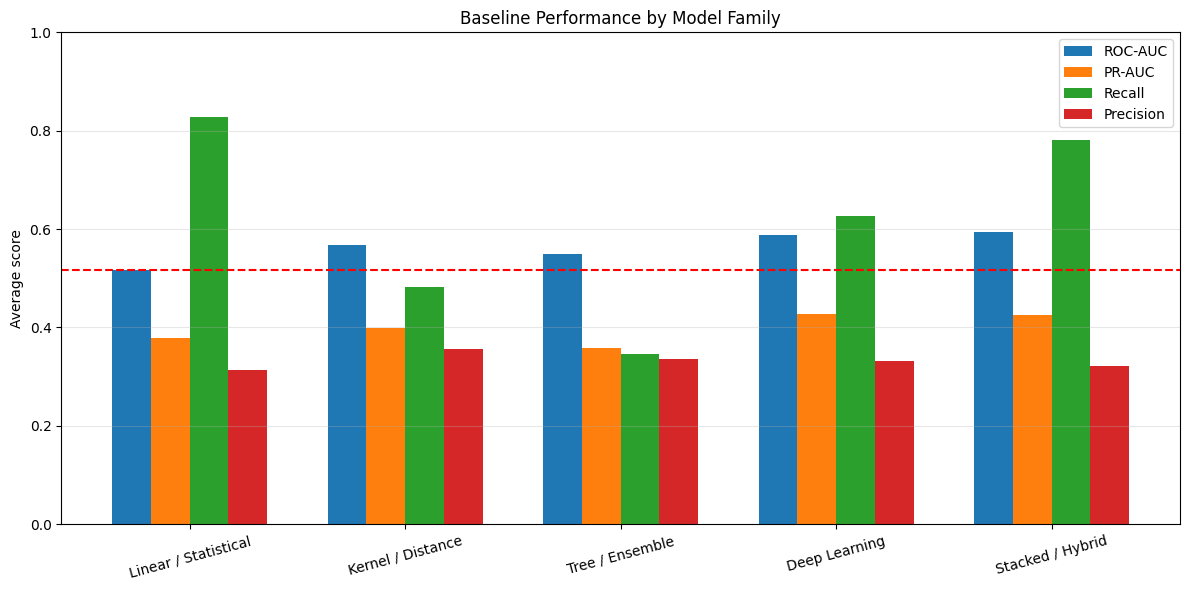

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

family_map = {
    "Logistic Regression": "Linear / Statistical",
    "Linear Discriminant Analysis": "Linear / Statistical",
    "Quadratic Discriminant Analysis": "Linear / Statistical",
    "Gaussian Naive Bayes": "Linear / Statistical",

    "Random Forest": "Tree / Ensemble",
    "Extra Trees": "Tree / Ensemble",
    "AdaBoost": "Tree / Ensemble",
    "Histogram Gradient Boosting": "Tree / Ensemble",
    "LightGBM": "Tree / Ensemble",
    "XGBoost": "Tree / Ensemble",
    "CatBoost": "Tree / Ensemble",

    "Support Vector Machine": "Kernel / Distance",
    "K-Nearest Neighbors": "Kernel / Distance",

    "MLP Neural Net": "Deep Learning",
    "TabNet": "Deep Learning",
    "TabNet (Deep Learning)": "Deep Learning",

    "Soft Voting Machine": "Stacked / Hybrid",
    "Voting Ensemble": "Stacked / Hybrid"
}

family_df = combined_results_df.copy()
family_df["Family"] = family_df["Model"].map(family_map)

summary_df = (
    family_df.groupby("Family")[["ROC-AUC", "PR-AUC", "Recall", "Precision"]]
    .mean()
    .reset_index()
)

family_order = [
    "Linear / Statistical",
    "Kernel / Distance",
    "Tree / Ensemble",
    "Deep Learning",
    "Stacked / Hybrid"
]
summary_df["Family"] = pd.Categorical(summary_df["Family"], categories=family_order, ordered=True)
summary_df = summary_df.sort_values("Family")

x = range(len(summary_df))
width = 0.18

plt.figure(figsize=(12, 6))
plt.bar([i - 1.5*width for i in x], summary_df["ROC-AUC"], width=width, label="ROC-AUC")
plt.bar([i - 0.5*width for i in x], summary_df["PR-AUC"], width=width, label="PR-AUC")
plt.bar([i + 0.5*width for i in x], summary_df["Recall"], width=width, label="Recall")
plt.bar([i + 1.5*width for i in x], summary_df["Precision"], width=width, label="Precision")

plt.xticks(list(x), summary_df["Family"], rotation=15)
plt.axhline(y=0.5169585, color='red', linestyle='--')
plt.ylim(0, 1)
plt.ylabel("Average score")
plt.title("Baseline Performance by Model Family")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)
tuned_results = []

param_grids = {
    "Random Forest": {
        'n_estimators': [200, 400, 600],
        'max_depth': [8, 15, 25, None],
        'min_samples_leaf': [1, 2, 5],
        'max_features': ['sqrt', 'log2', 0.3]
    },
    "MLP Neural Net": {
        'hidden_layer_sizes': [(128,), (128, 64), (256, 128, 64)],
        'alpha': [0.0001, 0.001, 0.01],
        'learning_rate_init': [0.001, 0.005],
        'activation': ['relu']
    },
    "Support Vector Machine": {
        'C': [1, 10, 100],
        'gamma': ['scale', 0.01, 0.1],
        'kernel': ['rbf']
    }
}

base_models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "MLP Neural Net": MLPClassifier(random_state=42, max_iter=1000, early_stopping=True),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

tuned_models = {}

for name in base_models.keys():

    search = RandomizedSearchCV(
        estimator=base_models[name],
        param_distributions=param_grids[name],
        n_iter=15,
        scoring='roc_auc',
        cv=tscv,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    tuned_models[name] = best_model

    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:, 1]

    results = evaluate_model_performance(f"{name} (Tuned)", y_val, y_pred, y_prob)
    tuned_results.append(results)

    print(f"Best ROC-AUC (CV): {search.best_score_:.4f}")
    print(f"Best Params: {search.best_params_}")

Best ROC-AUC (CV): 0.4834
Best Params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 8}
Best ROC-AUC (CV): 0.4617
Best Params: {'learning_rate_init': 0.005, 'hidden_layer_sizes': (128, 64), 'alpha': 0.001, 'activation': 'relu'}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=15. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best ROC-AUC (CV): 0.4804
Best Params: {'kernel': 'rbf', 'gamma': 0.1, 'C': 10}


In [ ]:
from sklearn.ensemble import VotingClassifier

best_rf = tuned_models["Random Forest"]
best_mlp = tuned_models["MLP Neural Net"]
best_svc = tuned_models["Support Vector Machine"]

tuned_voting_clf = VotingClassifier(
    estimators=[('mlp', best_mlp), ('rf', best_rf), ('svc', best_svc)],
    voting='soft'
)

tuned_voting_clf.fit(X_train, y_train)
tuned_models["Voting Ensemble"] = tuned_voting_clf

y_pred_vote = tuned_voting_clf.predict(X_val)
y_prob_vote = tuned_voting_clf.predict_proba(X_val)[:, 1]

vote_results = evaluate_model_performance("Voting Ensemble (Tuned)", y_val, y_pred_vote, y_prob_vote)
tuned_results.append(vote_results)

final_tuned_df = pd.DataFrame(tuned_results)
print("\n=== FINAL OPTIMIZED ARCHITECTURES (PRE-THRESHOLD TUNING) ===")
print(final_tuned_df.to_string(index=False))


=== FINAL OPTIMIZED ARCHITECTURES (PRE-THRESHOLD TUNING) ===
                         Model   Recall  Precision  F2 Score   PR-AUC  ROC-AUC
         Random Forest (Tuned) 0.446262   0.492268  0.454762 0.414157 0.620137
        MLP Neural Net (Tuned) 0.607477   0.344371  0.526956 0.461197 0.601610
Support Vector Machine (Tuned) 0.018692   0.347826  0.023055 0.367936 0.573677
       Voting Ensemble (Tuned) 0.595794   0.353186  0.523829 0.419524 0.595421


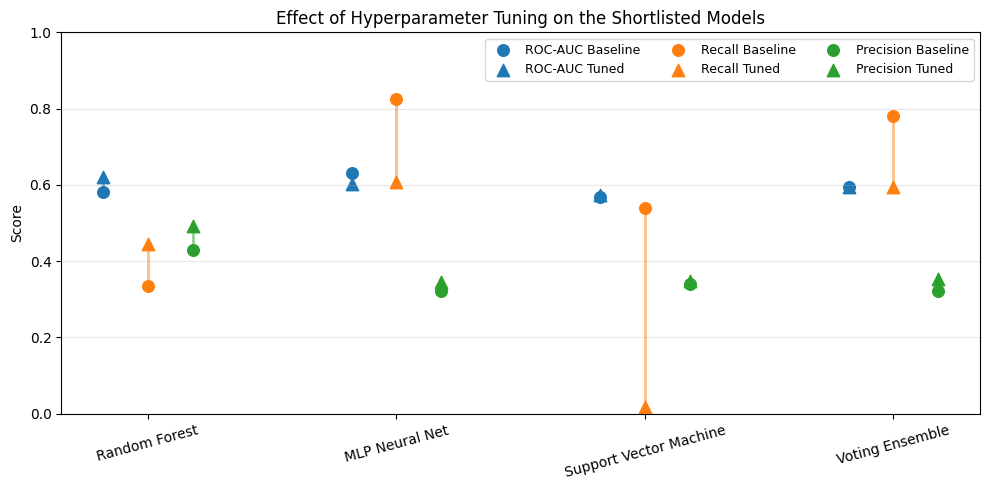

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

baseline_short = combined_results_df[
    combined_results_df["Model"].isin([
        "Random Forest", "MLP Neural Net", "Support Vector Machine", "Soft Voting Ensemble"
    ])
].copy()

baseline_short = baseline_short.replace({
    "Soft Voting Ensemble": "Voting Ensemble"
})

baseline_short = baseline_short[["Model", "ROC-AUC", "Recall", "Precision"]].copy()

tuned_short = final_tuned_df.copy()
tuned_short["Model"] = tuned_short["Model"].str.replace(" \\(Tuned\\)", "", regex=True)
tuned_short = tuned_short[["Model", "ROC-AUC", "Recall", "Precision"]].copy()

compare_df = baseline_short.merge(tuned_short, on="Model", suffixes=("_Baseline", "_Tuned"))

model_order = ["Random Forest", "MLP Neural Net", "Support Vector Machine", "Voting Ensemble"]
compare_df["Model"] = pd.Categorical(compare_df["Model"], categories=model_order, ordered=True)
compare_df = compare_df.sort_values("Model").reset_index(drop=True)

metrics = ["ROC-AUC", "Recall", "Precision"]
offsets = {"ROC-AUC": -0.18, "Recall": 0.0, "Precision": 0.18}
colors = {"ROC-AUC": "tab:blue", "Recall": "tab:orange", "Precision": "tab:green"}

x = np.arange(len(compare_df))

plt.figure(figsize=(10, 5))

for metric in metrics:
    xb = x + offsets[metric]
    yb = compare_df[f"{metric}_Baseline"]
    yt = compare_df[f"{metric}_Tuned"]

    for xi, y1, y2 in zip(xb, yb, yt):
        plt.plot([xi, xi], [y1, y2], color=colors[metric], alpha=0.5, linewidth=2)

    plt.scatter(xb, yb, color=colors[metric], marker="o", s=70, label=f"{metric} Baseline")
    plt.scatter(xb, yt, color=colors[metric], marker="^", s=80, label=f"{metric} Tuned")

plt.xticks(x, compare_df["Model"], rotation=15)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Effect of Hyperparameter Tuning on the Shortlisted Models")
plt.grid(axis="y", alpha=0.3)

# Remove duplicate legend entries
handles, labels = plt.gca().get_legend_handles_labels()
seen = {}
new_handles, new_labels = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        new_handles.append(h)
        new_labels.append(l)
plt.legend(new_handles, new_labels, ncol=3, fontsize=9)

plt.tight_layout()
plt.show()

## Threshold Tuning


=== FINAL THRESHOLD-OPTIMIZED PERFORMANCE ===
                 Model  Opt_Threshold   Recall  Precision  F2 Score
         Random Forest           0.39 0.834112   0.329032  0.638184
        MLP Neural Net           0.50 0.000000   0.000000  0.000000
Support Vector Machine           0.44 0.803738   0.313869  0.612536
       Voting Ensemble           0.30 0.822430   0.310954  0.618847


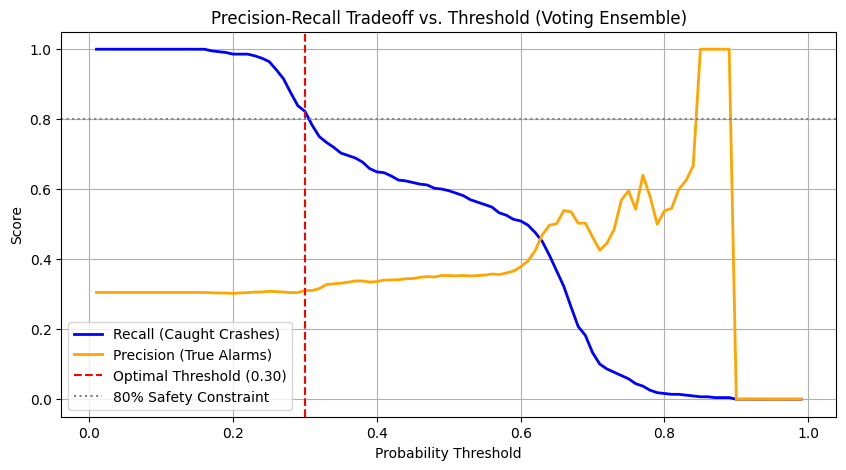

In [ ]:
import matplotlib.pyplot as plt

thresholds = np.linspace(0.01, 0.99, 99)
optimized_results = []

final_models = {
    "Random Forest": tuned_models.get("Random Forest"),
    "MLP Neural Net": tuned_models.get("MLP Neural Net"),
    "Support Vector Machine": tuned_models.get("Support Vector Machine"),
    "Voting Ensemble": tuned_models.get("Voting Ensemble")
}

for name, model in final_models.items():
    if model is None:
        continue

    y_prob = model.predict_proba(X_val)[:, 1]
    y_true_eval = y_val

    best_precision = -1
    best_metrics = None

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)

        precision = precision_score(y_true_eval, y_pred_t, zero_division=0)
        recall = recall_score(y_true_eval, y_pred_t, zero_division=0)
        f2 = fbeta_score(y_true_eval, y_pred_t, beta=2, zero_division=0)

        if recall >= 0.80:
          if precision > best_precision:
            best_precision = precision
            best_metrics = {
                "Threshold": t,
                "Recall": recall,
                "Precision": precision,
                "F2 Score": f2
            }

    if best_metrics is None:
        best_metrics = {"Threshold": 0.5, "Recall": 0.0, "Precision": 0.0, "F2 Score": 0.0}

    optimized_results.append({
        "Model": name,
        "Opt_Threshold": best_metrics["Threshold"],
        "Recall": best_metrics["Recall"],
        "Precision": best_metrics["Precision"],
        "F2 Score": best_metrics["F2 Score"]
    })

final_threshold_df = pd.DataFrame(optimized_results)
print("\n=== FINAL THRESHOLD-OPTIMIZED PERFORMANCE ===")
print(final_threshold_df.to_string(index=False))

best_model_probs = tuned_models["Voting Ensemble"].predict_proba(X_val)[:, 1]

recalls=[]
precisions=[]

for t in thresholds:
    y_pred_t = (best_model_probs >= t).astype(int)
    recalls.append(recall_score(y_val, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_val, y_pred_t, zero_division=0))

opt_t_vote = final_threshold_df.loc[final_threshold_df['Model'] == 'Voting Ensemble', 'Opt_Threshold'].values[0]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, recalls, color='blue', label='Recall (Caught Crashes)', linewidth=2)
plt.plot(thresholds, precisions, color='orange', label='Precision (True Alarms)', linewidth=2)
plt.axvline(x=opt_t_vote, color='red', linestyle='--', label=f'Optimal Threshold ({opt_t_vote:.2f})')
plt.axhline(y=0.80, color='gray', linestyle=':', label='80% Safety Constraint')
plt.title("Precision-Recall Tradeoff vs. Threshold (Voting Ensemble)")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

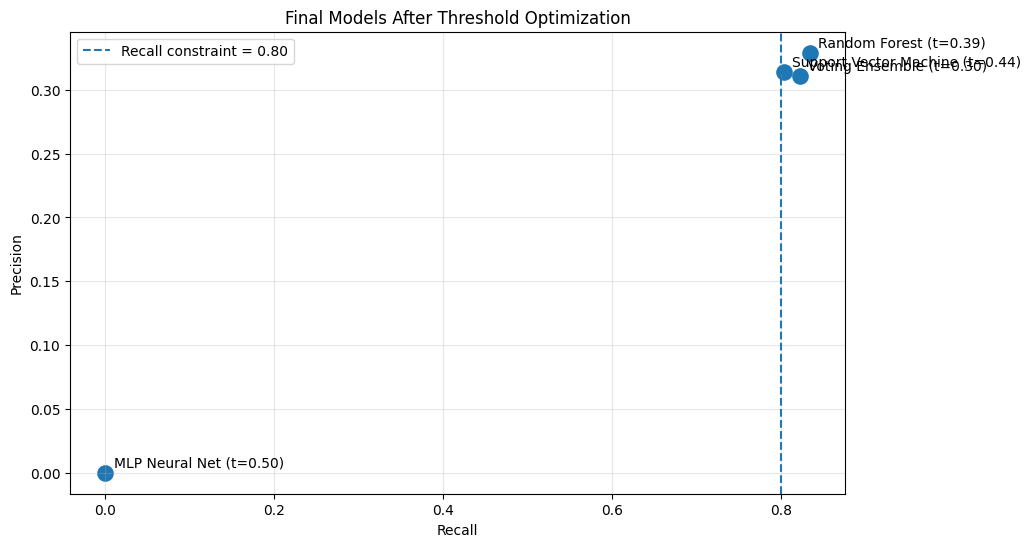

In [ ]:
threshold_df = pd.DataFrame(optimized_results).sort_values("F2 Score", ascending=False)

plt.figure(figsize=(10, 6))
plt.scatter(threshold_df["Recall"], threshold_df["Precision"], s=120)

for _, row in threshold_df.iterrows():
    plt.annotate(
        f"{row['Model']} (t={row['Opt_Threshold']:.2f})",
        (row["Recall"], row["Precision"]),
        xytext=(6, 4),
        textcoords="offset points"
    )

plt.axvline(0.80, linestyle="--", label="Recall constraint = 0.80")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Models After Threshold Optimization")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

1. Optimal Threshold = 0.3 (cap recall at 0.8 and precision at ~0.3)
    - If the threshold keep moving towards 1.0, the recall will drop below 0.8 which we don't hope so.

2. MLP Neural Net: Deep neural networks suffer from probability compression.
    - THe MLP can't hit an 80% recall rate at any standard threshold.

Key Insights from Financial Dataset:
- ROC AUC score will evaluate whether the model is able to learn useful information from the 111 feature columns, so it can recognize the patterns and differentiate the downturn case
- But the 111 features are insufficient to identify a downturn case, where the best model achieves ~0.62 (Random, useless dataset -> 0.5), proving that the models did find real, distinct patterns among the features.
- May apply feature pruning if want to reduce the noises in the dataset.

While training a model to maintain the performance of recall ~ 0.8 and precision ~ 0.6/0.7 is nearly impossible, we can print billions of dollars if we able to do that.

Till here:
- Models are trained on dataset from 1991-2013, validated on dataset from 2013-2019
- Test set are clean, unseen (2019-2025)

## Train 4 models & Extract data from 2008-2025

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

print("=== ALIGNING PIPELINE TO 2008-2025 & GENERATING OOF PREDICTIONS ===")

# 1. Filter the ENTIRE dataset to start exactly when the Sentiment data starts
df_base = df.copy()
df_base['Date'] = pd.to_datetime(df_base['Date'])
df_modern = df_base[df_base['Date'] >= '2008-11-24'].reset_index(drop=True)

print(f"Original Dataset Size: {df_base.shape[0]} trading days")
print(f"Modern Era Size (2008-2025): {df_modern.shape[0]} continuous trading days\n")

# 2. Separate into Meta-Train (2008-2021) and Meta-Test (2022-2025)
train_mask = df_modern['Date'] < '2022-01-01'
test_mask = df_modern['Date'] >= '2022-01-01'

df_meta_train = df_modern[train_mask].reset_index(drop=True)
df_meta_test = df_modern[test_mask].reset_index(drop=True)

# 3. Safely define feature columns and SCALE WITH A FRESH SCALER
drop_cols = ['Date', 'downturn_target', 'future_min_30d', 'future_return_30d']
feature_cols = [col for col in df_modern.columns if col not in drop_cols]

# We use base_scaler here to completely avoid clashes with the meta-learner scaler
base_scaler = StandardScaler()
X_meta_train = base_scaler.fit_transform(df_meta_train[feature_cols])
X_meta_test = base_scaler.transform(df_meta_test[feature_cols])

y_meta_train = df_meta_train['downturn_target'].values
y_meta_test = df_meta_test['downturn_target'].values

# Setup DataFrames to hold the unbiased predictions
bridge_train = pd.DataFrame({'Date': df_meta_train['Date'], 'True_Downturn': y_meta_train})
bridge_test = pd.DataFrame({'Date': df_meta_test['Date'], 'True_Downturn': y_meta_test})

prob_cols = ['Base_RF_Prob', 'Base_SVM_Prob', 'Base_Voting_Prob']
for col in prob_cols:
    bridge_train[col] = np.nan
    bridge_test[col] = np.nan

# 4. Generate Out-of-Fold (OOF) Predictions for the Training Set (2008-2021)
tscv = TimeSeriesSplit(n_splits=5)

base_rf = clone(tuned_models["Random Forest"])
base_svm = clone(tuned_models["Support Vector Machine"])
base_voting = clone(tuned_models["Voting Ensemble"])

print("--> Running TimeSeriesSplit to generate unbiased training probabilities...")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_meta_train)):
    print(f"    Processing Fold {fold+1}/5...")
    X_fold_train, X_fold_val = X_meta_train[train_idx], X_meta_train[val_idx]
    y_fold_train, y_fold_val = y_meta_train[train_idx], y_meta_train[val_idx]

    base_rf.fit(X_fold_train, y_fold_train)
    base_svm.fit(X_fold_train, y_fold_train)
    base_voting.fit(X_fold_train, y_fold_train)

    bridge_train.loc[val_idx, 'Base_RF_Prob'] = base_rf.predict_proba(X_fold_val)[:, 1]
    bridge_train.loc[val_idx, 'Base_SVM_Prob'] = base_svm.predict_proba(X_fold_val)[:, 1]
    bridge_train.loc[val_idx, 'Base_Voting_Prob'] = base_voting.predict_proba(X_fold_val)[:, 1]

bridge_train = bridge_train.dropna().reset_index(drop=True)

# 5. Generate Standard Predictions for the Test Set (2022-2025)
print("--> Generating Test Set probabilities (training on full 2008-2021 history)...")
base_rf.fit(X_meta_train, y_meta_train)
base_svm.fit(X_meta_train, y_meta_train)
base_voting.fit(X_meta_train, y_meta_train)

bridge_test['Base_RF_Prob'] = base_rf.predict_proba(X_meta_test)[:, 1]
bridge_test['Base_SVM_Prob'] = base_svm.predict_proba(X_meta_test)[:, 1]
bridge_test['Base_Voting_Prob'] = base_voting.predict_proba(X_meta_test)[:, 1]

# 6. Combine everything into the final bridge
bridge_df = pd.concat([bridge_train, bridge_test], ignore_index=True)

print("\n=== MODERN OOF STACKING COMPLETE ===")
print("Bridge DataFrame Shape:", bridge_df.shape)
bridge_df.to_csv("financial_bridge_probs_2008_2025.csv", index=False)

=== ALIGNING PIPELINE TO 2008-2025 & GENERATING OOF PREDICTIONS ===
Original Dataset Size: 8765 trading days
Modern Era Size (2008-2025): 4335 continuous trading days

--> Running TimeSeriesSplit to generate unbiased training probabilities...
    Processing Fold 1/5...
    Processing Fold 2/5...
    Processing Fold 3/5...
    Processing Fold 4/5...
    Processing Fold 5/5...
--> Generating Test Set probabilities (training on full 2008-2021 history)...

=== MODERN OOF STACKING COMPLETE ===
Bridge DataFrame Shape: (3781, 5)


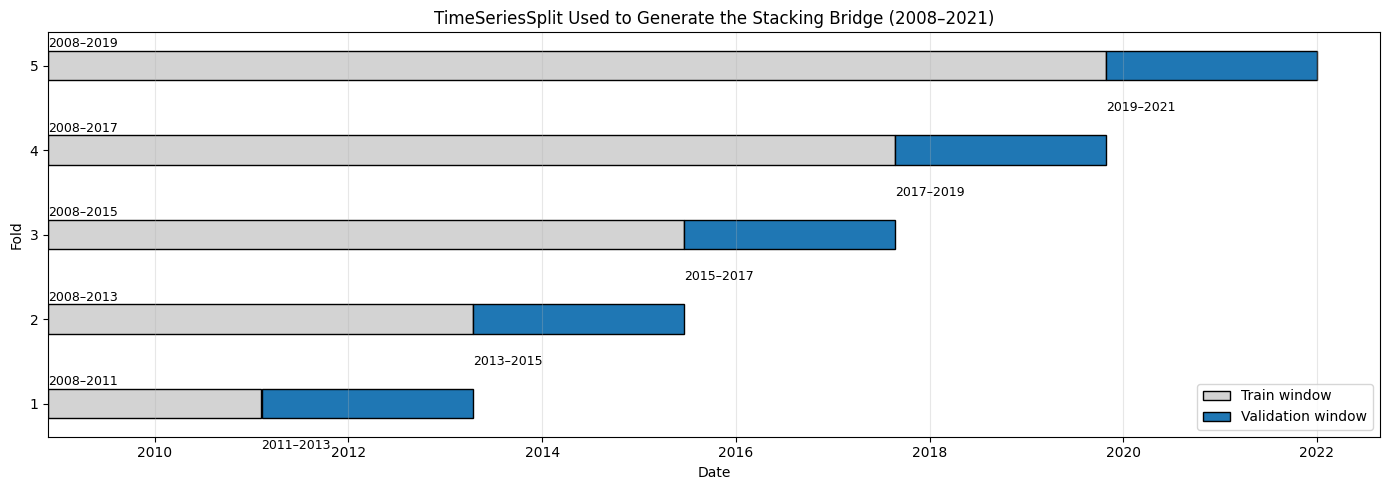

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd

tscv = TimeSeriesSplit(n_splits=5)
dates = pd.to_datetime(df_meta_train["Date"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 5))

for fold, (train_idx, val_idx) in enumerate(tscv.split(df_meta_train), start=1):
    train_start = dates.iloc[train_idx[0]]
    train_end = dates.iloc[train_idx[-1]]
    val_start = dates.iloc[val_idx[0]]
    val_end = dates.iloc[val_idx[-1]]

    # Training block
    ax.barh(
        y=fold,
        width=(train_end - train_start).days,
        left=train_start,
        height=0.35,
        color="lightgray",
        edgecolor="black",
        label="Train window" if fold == 1 else ""
    )

    # Validation block
    ax.barh(
        y=fold,
        width=(val_end - val_start).days,
        left=val_start,
        height=0.35,
        color="tab:blue",
        edgecolor="black",
        label="Validation window" if fold == 1 else ""
    )

    ax.text(train_start, fold + 0.18, f"{train_start.year}–{train_end.year}", fontsize=9, va="bottom")
    ax.text(val_start, fold - 0.42, f"{val_start.year}–{val_end.year}", fontsize=9, va="top")

ax.set_title("TimeSeriesSplit Used to Generate the Stacking Bridge (2008–2021)")
ax.set_xlabel("Date")
ax.set_ylabel("Fold")
ax.set_yticks(range(1, 6))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(axis="x", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Color coding, chronological index (instead, using years)

In [ ]:
df_stack = pd.read_csv("financial_bridge_probs_2008_2025.csv")
df_stack['Date'] = pd.to_datetime(df_stack['Date'])

sentiment_df = pd.read_csv("combined_daily_sentiment_results.csv")
sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
sentiment_df = sentiment_df[sentiment_df['date'] >= '2008-11-24'].copy().sort_values('date')

sentiment_df['ema_sentiment'] = sentiment_df['weighted_sentiment'].ewm(span=3, adjust=False).mean()
sentiment_df['ema_momentum'] = sentiment_df['momentum'].ewm(span=3, adjust=False).mean()

print(f"Loaded Financial Bridge: {df_stack.shape[0]} trading days")
print(f"Loaded Reddit Sentiment: {sentiment_df.shape[0]} calendar days\n")

trading_dates = pd.DataFrame({'Trading_Date': df_stack['Date'].sort_values().unique()})
# calendar_dates = pd.DataFrame({'date': sentiment_df['date'].unique()})

calendar_mapped = pd.merge_asof(
    sentiment_df,
    trading_dates,
    left_on='date',
    right_on='Trading_Date',
    direction='forward'
)

agg_sentiment = calendar_mapped.groupby('Trading_Date').agg(
    total_mentions=('total_mentions', 'sum'),           # Rule: Sum volume
    momentum=('ema_momentum', 'last'),                      # Rule: Average momentum
    weighted_sentiment=('ema_sentiment', 'last')   # Rule: Average sentiment
).reset_index()

ultimate_stack_df = pd.merge(
    bridge_df,
    agg_sentiment,
    left_on='Date',
    right_on='Trading_Date',
    how='left'
)

ultimate_stack_df.drop(columns=['Trading_Date'], inplace=True)
ultimate_stack_df['momentum'] = ultimate_stack_df['momentum'].fillna(0)
ultimate_stack_df['weighted_sentiment'] = ultimate_stack_df['weighted_sentiment'].fillna(0.5)
ultimate_stack_df['total_mentions'] = ultimate_stack_df['total_mentions'].fillna(0)

print("\n=== STEP 3 COMPLETE ===")
print("Ultimate Stacking Dataset Shape:", ultimate_stack_df.shape)
print("\nFirst 10 rows of the Final Stacking Data:")
print(ultimate_stack_df[['Date', 'True_Downturn', 'Base_Voting_Prob', 'weighted_sentiment', 'momentum', 'total_mentions']].head(10).to_string())

ultimate_stack_df.to_csv("ultimate_stacking_dataset_2008_2025.csv", index=False)
print("\nSaved successfully as 'ultimate_stacking_dataset_2008_2025.csv'")

Loaded Financial Bridge: 3781 trading days
Loaded Reddit Sentiment: 3848 calendar days


=== STEP 3 COMPLETE ===
Ultimate Stacking Dataset Shape: (3781, 8)

First 10 rows of the Final Stacking Data:
        Date  True_Downturn  Base_Voting_Prob  weighted_sentiment  momentum  total_mentions
0 2011-02-07              1          0.864940            0.403068       0.0            68.0
1 2011-02-08              1          0.916082            0.470602       0.0             9.0
2 2011-02-09              1          0.813603            0.500000       0.0             0.0
3 2011-02-10              1          0.828734            0.500000       0.0             0.0
4 2011-02-11              1          0.751539            0.500000       0.0             0.0
5 2011-02-14              1          0.693909            0.500000       0.0             0.0
6 2011-02-15              1          0.725120            0.500000       0.0             0.0
7 2011-02-16              1          0.687204            0.500000

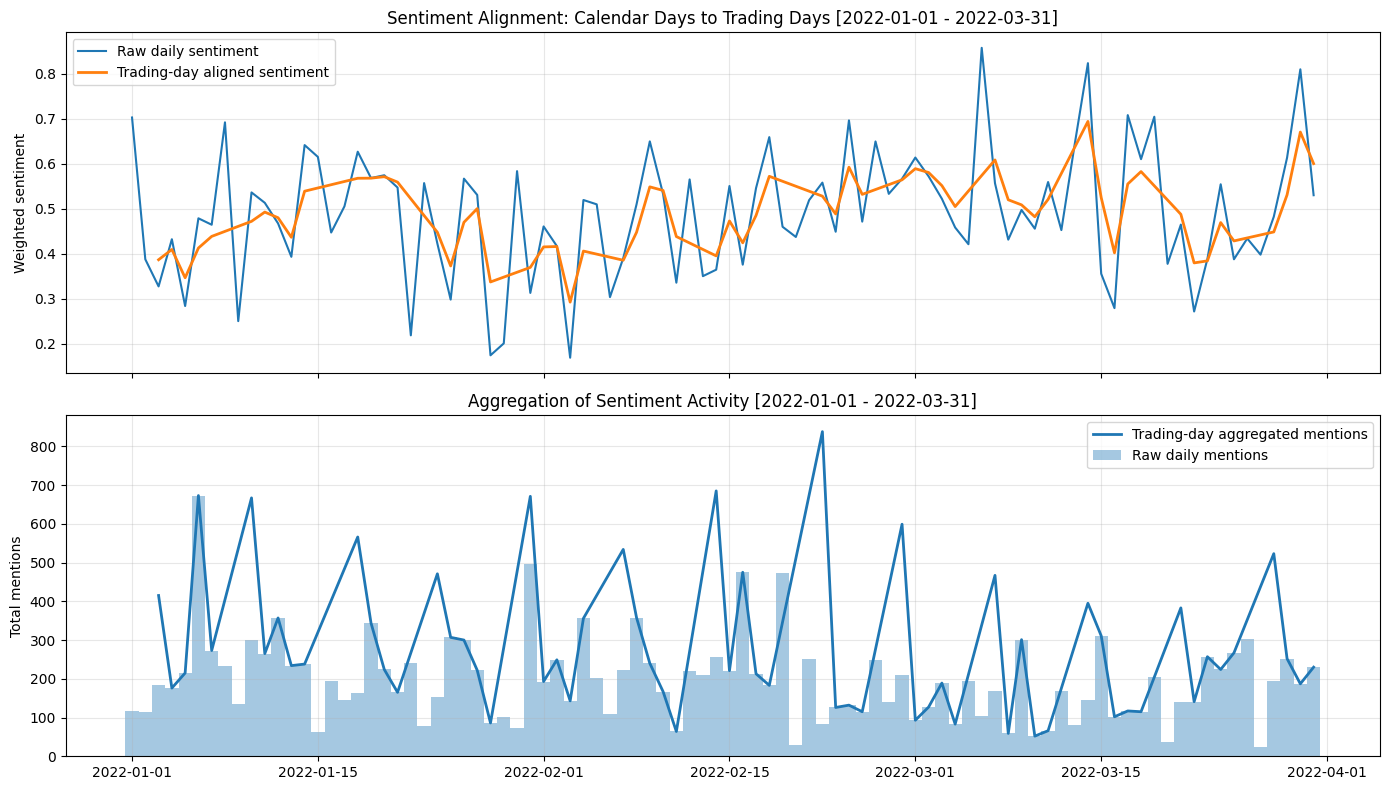

In [ ]:
import matplotlib.pyplot as plt

# Choose a short window to make the weekend alignment visible
viz_start = "2022-01-01"
viz_end = "2022-03-31"

raw_sent_viz = sentiment_df[(sentiment_df["date"] >= viz_start) & (sentiment_df["date"] <= viz_end)].copy()
agg_sent_viz = agg_sentiment[(agg_sentiment["Trading_Date"] >= viz_start) & (agg_sentiment["Trading_Date"] <= viz_end)].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Weighted sentiment
axes[0].plot(raw_sent_viz["date"], raw_sent_viz["weighted_sentiment"], label="Raw daily sentiment")
axes[0].plot(agg_sent_viz["Trading_Date"], agg_sent_viz["weighted_sentiment"], linewidth=2, label="Trading-day aligned sentiment")
axes[0].set_title("Sentiment Alignment: Calendar Days to Trading Days [2022-01-01 - 2022-03-31]")
axes[0].set_ylabel("Weighted sentiment")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Total mentions
axes[1].bar(raw_sent_viz["date"], raw_sent_viz["total_mentions"], width=1.0, alpha=0.4, label="Raw daily mentions")
axes[1].plot(agg_sent_viz["Trading_Date"], agg_sent_viz["total_mentions"], linewidth=2, label="Trading-day aggregated mentions")
axes[1].set_title("Aggregation of Sentiment Activity [2022-01-01 - 2022-03-31]")
axes[1].set_ylabel("Total mentions")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Applying Exponential Moving Average (EMA) to the calendar days before snapping them to the trading days. Ensuring a massive panic on Saturday structurally carries over into Monday's opening bell.

Justifications for integrating `combined_daily_sentiment_results.csv` and dropping columns such as `sentiment_ma7`, `sentiment_ma30`, `num_tickers`

In [ ]:
df_stack = pd.read_csv("ultimate_stacking_dataset_2008_2025.csv")
df_stack['Date'] = pd.to_datetime(df_stack['Date'])

df_stack['Financial_Panic_Interaction'] = df_stack['Base_Voting_Prob'] * df_stack['momentum']

# Train: 2008 through 2021 | Test: Unseen 2022 to 2025
train_val_mask = df_stack['Date'] < '2022-01-01'
test_mask = df_stack['Date'] >= '2022-01-01'

train_val_df = df_stack[train_val_mask].reset_index(drop=True)
test_df = df_stack[test_mask].reset_index(drop=True)

print(f"Training 'The Boss' on {len(train_val_df)} days (2008-2021)...")
print(f"Testing 'The Boss' on {len(test_df)} unseen days (2022-2025)...\n")

meta_features = [
    'Base_RF_Prob', 'Base_SVM_Prob', 'Base_Voting_Prob',
    'weighted_sentiment', 'momentum', 'total_mentions', 'Financial_Panic_Interaction'
]

X_train_val = train_val_df[meta_features]
y_train_val = train_val_df['True_Downturn']
X_test = test_df[meta_features]
y_test = test_df['True_Downturn']

scaler = StandardScaler()
X_train_val_scaled = scaler.fit_transform(X_train_val)
X_test_scaled = scaler.transform(X_test)

tscv = TimeSeriesSplit(n_splits=5)
fold_thresholds = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_val_scaled)):
    X_fold_train, X_fold_val = X_train_val_scaled[train_idx], X_train_val_scaled[val_idx]
    y_fold_train, y_fold_val = y_train_val.iloc[train_idx], y_train_val.iloc[val_idx]

    model = LogisticRegression(random_state=42, C=1.0)
    model.fit(X_fold_train, y_fold_train)
    val_probs = model.predict_proba(X_fold_val)[:, 1]

    # Find best threshold for this specific fold
    best_t = 0.5
    best_prec = -1
    for t in np.linspace(0.01, 0.99, 99):
        y_pred = (val_probs >= t).astype(int)
        rec = recall_score(y_fold_val, y_pred, zero_division=0)
        prec = precision_score(y_fold_val, y_pred, zero_division=0)
        if rec >= 0.80 and prec > best_prec:
            best_prec = prec
            best_t = t

    fold_thresholds.append(best_t)
    print(f"   Fold {fold+1} Optimal Threshold: {best_t:.2f}")

locked_threshold = np.mean(fold_thresholds)
print(f"\n--> Averaged Validated Threshold Locked At: {locked_threshold:.2f}")

final_meta = LogisticRegression(random_state=42, C=1.0)
final_meta.fit(X_train_val_scaled, y_train_val)

print("\n=== FINAL META-LEARNER LOGIC (Feature Weights) ===")
importance_df = pd.DataFrame({
    'Feature': meta_features,
    'Weight (Coefficient)': final_meta.coef_[0]
}).sort_values(by='Weight (Coefficient)', ascending=False)
print(importance_df.to_string(index=False))
print("-" * 50)

blind_test_probs = final_meta.predict_proba(X_test_scaled)[:, 1]
blind_predictions = (blind_test_probs >= locked_threshold).astype(int)

final_recall = recall_score(y_test, blind_predictions, zero_division=0)
final_precision = precision_score(y_test, blind_predictions, zero_division=0)

print("\n=== MATHEMATICALLY BULLETPROOF PERFORMANCE (2022-2025) ===")
print(f"Locked Threshold: {locked_threshold:.2f}")
print(f"Blind Test Recall: {final_recall:.4f}")
print(f"Blind Test Precision: {final_precision:.4f}")

Training 'The Boss' on 2745 days (2008-2021)...
Testing 'The Boss' on 1036 unseen days (2022-2025)...

   Fold 1 Optimal Threshold: 0.26
   Fold 2 Optimal Threshold: 0.23
   Fold 3 Optimal Threshold: 0.17
   Fold 4 Optimal Threshold: 0.12
   Fold 5 Optimal Threshold: 0.24

--> Averaged Validated Threshold Locked At: 0.20

=== FINAL META-LEARNER LOGIC (Feature Weights) ===
                    Feature  Weight (Coefficient)
           Base_Voting_Prob              0.382971
Financial_Panic_Interaction              0.121372
              Base_SVM_Prob             -0.011856
         weighted_sentiment             -0.035429
             total_mentions             -0.083057
                   momentum             -0.118156
               Base_RF_Prob             -0.322446
--------------------------------------------------

=== MATHEMATICALLY BULLETPROOF PERFORMANCE (2022-2025) ===
Locked Threshold: 0.20
Blind Test Recall: 0.8889
Blind Test Precision: 0.4295


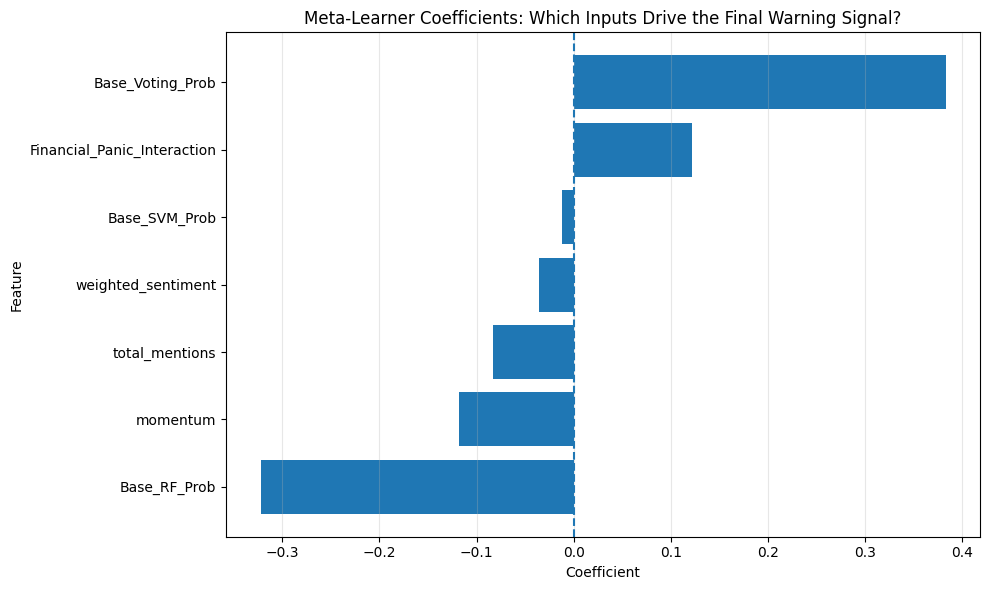

In [ ]:
import matplotlib.pyplot as plt

coef_plot_df = importance_df.sort_values("Weight (Coefficient)")

plt.figure(figsize=(10, 6))
plt.barh(coef_plot_df["Feature"], coef_plot_df["Weight (Coefficient)"])
plt.axvline(0, linestyle="--")
plt.title("Meta-Learner Coefficients: Which Inputs Drive the Final Warning Signal?")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Previous pure financial dataset: `recall = ~0.8`, `precision = ~0.34`
Latest combined dataset: `recall = ~0.9`, `precision = 0.43`

Meta Learner's Mind
- Heavyweights: SVM, RF are massive positive drivers. They are relied heavily to detect macroeconomic fragility.
- VE, TabNet are redundant
- Reddit features are all negative, implying bigger Reddit tends to tell us everything is ok, keep buying. A bullish indicator.
    - LogReg-based learner, goal is to predict crash (1)
    - Reddit -> tends to 0

# Final Export


In [ ]:
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

print("=== INITIATING PRODUCTION RETRAINING (BASE MODELS) ===\n")

# STRICT FIREWALL: Drop 2026 (The Holdout/OOT Period)
df_full = df_modern[df_modern['Date'] <= '2025-12-31'].dropna(subset=["future_min_30d"]).reset_index(drop=True)

# Define features safely (just in case)
drop_cols = ["Date", "downturn_target", "future_min_30d", "future_return_30d"]
feature_cols = [c for c in df_full.columns if c not in drop_cols]

X_full = df_full[feature_cols]
y_full = df_full["downturn_target"]

print(f"Full Production Dataset Shape: {X_full.shape[0]} days (2008 to Dec 2025)")

# Fit the FINAL Production Scaler on this blinded data
production_scaler = StandardScaler()
X_full_scaled_np = production_scaler.fit_transform(X_full)
y_full_np = y_full.values

# Retrain the best models
print("--> Retraining Models on blinded data...")
prod_rf = tuned_models["Random Forest"]
prod_rf.fit(X_full_scaled_np, y_full_np)

prod_svm = tuned_models["Support Vector Machine"]
prod_svm.fit(X_full_scaled_np, y_full_np)

prod_voting = tuned_models["Voting Ensemble"]
prod_voting.fit(X_full_scaled_np, y_full_np)

# Export the Master Artifacts
print("\n--> Exporting Deployment Artifacts...")
joblib.dump(production_scaler, 'financial_scaler_prod.pkl')
joblib.dump(prod_rf, 'rf_base_prod.pkl')
joblib.dump(prod_svm, 'svm_base_prod.pkl')
joblib.dump(prod_voting, 'voting_base_prod.pkl')

print("SUCCESS: Base models and scaler exported. 2026 data successfully withheld.")

=== INITIATING PRODUCTION RETRAINING (BASE MODELS) ===

Full Production Dataset Shape: 4302 days (2008 to Dec 2025)
--> Retraining Models on blinded data...

--> Exporting Deployment Artifacts...
SUCCESS: Base models and scaler exported. 2026 data successfully withheld.


In [ ]:
from sklearn.linear_model import LogisticRegression

print("\n=== INITIATING PRODUCTION RETRAINING (META-LEARNER) ===")

# Load the unified stacking dataset you saved earlier
df_stack_full = pd.read_csv("ultimate_stacking_dataset_2008_2025.csv")
df_stack_full['Date'] = pd.to_datetime(df_stack_full['Date'])

# STRICT FIREWALL: Drop any 2026 rows
df_stack_full = df_stack_full[df_stack_full['Date'] <= '2025-12-31'].reset_index(drop=True)

# Ensure interaction feature exists
df_stack_full['Financial_Panic_Interaction'] = df_stack_full['Base_Voting_Prob'] * df_stack_full['momentum']

meta_features = [
    'Base_RF_Prob', 'Base_SVM_Prob', 'Base_Voting_Prob',
    'weighted_sentiment', 'momentum', 'total_mentions', 'Financial_Panic_Interaction'
]

X_meta_full = df_stack_full[meta_features]
y_meta_full = df_stack_full['True_Downturn']

print(f"Retraining 'The Boss' on {len(X_meta_full)} days (2008 to Dec 2025)...")

# Scale and Train
meta_scaler = StandardScaler()
X_meta_full_scaled = meta_scaler.fit_transform(X_meta_full)

production_meta = LogisticRegression(random_state=42, C=1.0)
production_meta.fit(X_meta_full_scaled, y_meta_full)

# Export
joblib.dump(meta_scaler, 'meta_scaler_prod.pkl')
joblib.dump(production_meta, 'meta_learner_prod.pkl')

print("SUCCESS: Meta-Learner exported. 2026 data successfully withheld.")


=== INITIATING PRODUCTION RETRAINING (META-LEARNER) ===
Retraining 'The Boss' on 3748 days (2008 to Dec 2025)...
SUCCESS: Meta-Learner exported. 2026 data successfully withheld.


In [ ]:
import joblib
import pandas as pd

print("--> Loading and formatting datasets...")

# 1. Load the master financial dataset
df_holdout = pd.read_csv('feature_engineered_dataset.csv')
df_holdout['Date'] = pd.to_datetime(df_holdout['Date'])

HORIZON = 30
THRESHOLD = -0.03 # Ensure this matches the threshold you used for training!

future_min = pd.Series([
    df_holdout["SPX_PX_LAST"].iloc[i+1 : i+1+HORIZON].min()
    if i+1+HORIZON <= len(df_holdout) else np.nan
    for i in range(len(df_holdout))
])

df_holdout["future_min_30d"] = future_min.values
df_holdout["future_return_30d"] = df_holdout["future_min_30d"] / df_holdout["SPX_PX_LAST"] - 1

# SAFELY calculate downturn: if future is unknown (NaN), keep it NaN. Otherwise, 1 or 0.
df_holdout["downturn_target"] = np.where(
    df_holdout["future_return_30d"].isna(),
    np.nan,
    (df_holdout["future_return_30d"] <= THRESHOLD).astype(int)
)

# 2. Update the end_date to capture all the way up to early April
start_date = '2026-01-01'
end_date = '2026-04-15' # This will safely catch your max date of 2026-04-02

# Filter Financial Data for Jan-Apr 2026 holdout period
test_filtered = df_holdout[(df_holdout['Date'] >= start_date) & (df_holdout['Date'] <= end_date)].copy()

print(f"Financial holdout dataset prepared: {test_filtered['Date'].min().date()} to {test_filtered['Date'].max().date()}")

# Load sentiment data and align
sent_df = pd.read_csv('daily_sentiment_results.csv')

# FIX: Rename the columns from the new CSV to match what the Meta-Learner expects
sent_df = sent_df.rename(columns={
    'sentiment_score': 'weighted_sentiment',
    'post_count': 'total_mentions',
    'SMO': 'momentum'
})

sent_df['date'] = pd.to_datetime(sent_df['date'])
sent_df = sent_df.sort_values('date').set_index('date')

# Explicitly select ONLY numeric columns before resampling so Pandas doesn't crash
numeric_sentiment_cols = ['weighted_sentiment', 'total_mentions', 'momentum']
sent_daily = sent_df[numeric_sentiment_cols].resample('D').mean().fillna(0)

sent_ema = sent_daily.ewm(span=3, adjust=False).mean().reset_index()
sent_ema = sent_ema.rename(columns={'date': 'Date'})

merged_df = pd.merge(test_filtered, sent_ema, on='Date', how='left')

# Handle missing data
cols_to_fill = ['weighted_sentiment', 'total_mentions', 'momentum']
merged_df[cols_to_fill] = merged_df[cols_to_fill].bfill().fillna(0)

print(f"--> Data perfectly aligned. Total unseen trading days to simulate: {merged_df.shape[0]}\n")

print("--> Loading Production Models...")
financial_scaler = joblib.load('financial_scaler_prod.pkl')
rf_base = joblib.load('rf_base_prod.pkl')
svm_base = joblib.load('svm_base_prod.pkl')
voting_base = joblib.load('voting_base_prod.pkl')
meta_scaler = joblib.load('meta_scaler_prod.pkl')
meta_learner = joblib.load('meta_learner_prod.pkl')

# 1. Scale Financial Features (safely filtering out labels/dates)
drop_cols = ['Date', 'future_min_30d', 'future_return_30d', 'downturn_target']
financial_cols = [c for c in test_filtered.columns if c not in drop_cols]
X_live_fin_scaled = financial_scaler.transform(merged_df[financial_cols])

# 2. Generate Base Probabilities
print("--> Generating Level 1 Institutional Risk Probabilities...")
merged_df['Base_RF_Prob'] = rf_base.predict_proba(X_live_fin_scaled)[:, 1]
merged_df['Base_SVM_Prob'] = svm_base.predict_proba(X_live_fin_scaled)[:, 1]
merged_df['Base_Voting_Prob'] = voting_base.predict_proba(X_live_fin_scaled)[:, 1]

# 3. Calculate Feature Interaction
merged_df['Financial_Panic_Interaction'] = merged_df['Base_Voting_Prob'] * merged_df['momentum']

# 4. Meta-Features
meta_features = [
    'Base_RF_Prob', 'Base_SVM_Prob', 'Base_Voting_Prob',
    'weighted_sentiment', 'momentum', 'total_mentions', 'Financial_Panic_Interaction'
]
X_live_meta_scaled = meta_scaler.transform(merged_df[meta_features])

# 5. Final Boss Predictions
print("--> Executing Final Meta-Learner Predictions...")
merged_df['Predicted_Risk_Score'] = meta_learner.predict_proba(X_live_meta_scaled)[:, 1]

# Locked binary threshold from validated meta-learner
locked_threshold = 0.20

# Binary warning flag (keep this for formal evaluation if needed)
merged_df['Crash_Warning_Flag'] = (
    merged_df['Predicted_Risk_Score'] >= locked_threshold
).astype(int)

# 3-band risk interpretation layer
def assign_risk_band(score):
    if score < 0.20:
        return "Normal"
    elif score < 0.35:
        return "Elevated Risk"
    else:
        return "Crash Warning"

merged_df['Risk_Band'] = merged_df['Predicted_Risk_Score'].apply(assign_risk_band)

# 6. Export for Demo
merged_df = merged_df.rename(columns={'downturn_target': 'True_Downturn'})
export_columns = [
    'Date', 'True_Downturn', 'Predicted_Risk_Score', 'Risk_Band', 'Crash_Warning_Flag',
    'Base_RF_Prob', 'Base_SVM_Prob', 'Base_Voting_Prob',
    'weighted_sentiment', 'momentum', 'total_mentions', 'Financial_Panic_Interaction'
]

print("\nRisk band distribution:")
print(merged_df['Risk_Band'].value_counts())

demo_export_df = merged_df[export_columns]
filename = "jan_apr_2026_predictions.csv"
demo_export_df.to_csv(filename, index=False)

print(f"\nSUCCESS! Honest Demo data exported to: {filename}")

--> Loading and formatting datasets...
Financial holdout dataset prepared: 2026-01-02 to 2026-04-02
--> Data perfectly aligned. Total unseen trading days to simulate: 63

--> Loading Production Models...
--> Generating Level 1 Institutional Risk Probabilities...
--> Executing Final Meta-Learner Predictions...

Risk band distribution:
Risk_Band
Elevated Risk    44
Crash Warning    19
Name: count, dtype: int64

SUCCESS! Honest Demo data exported to: jan_apr_2026_predictions.csv


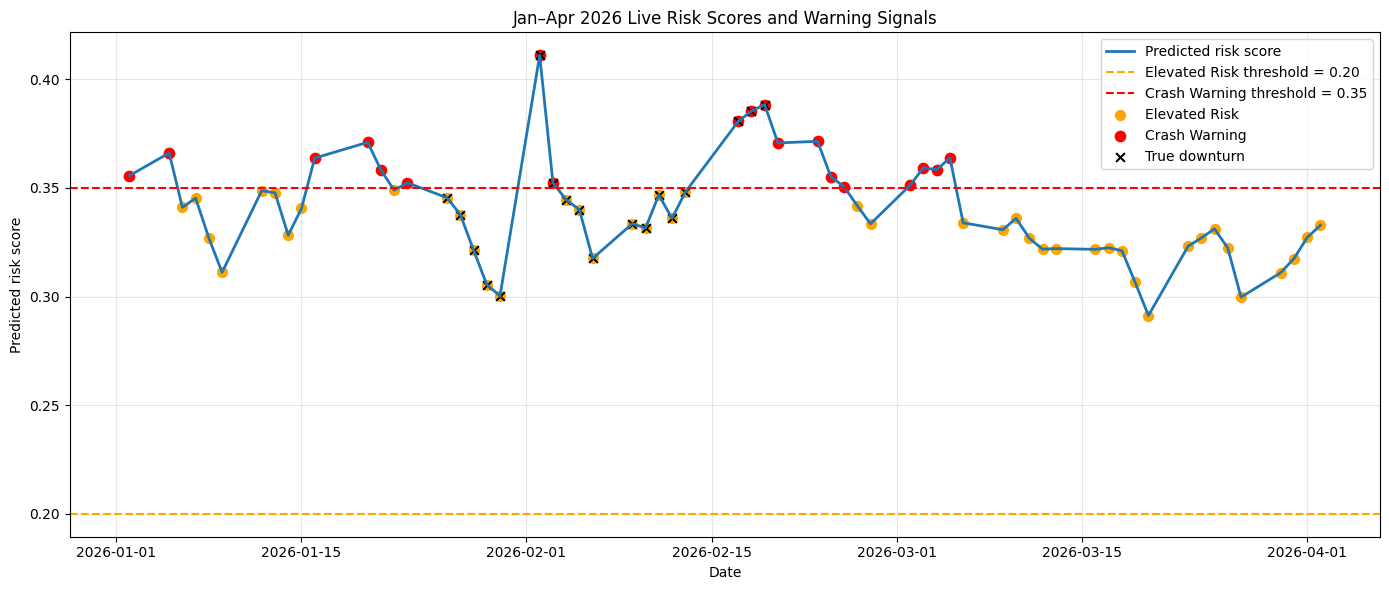

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Main risk score line
plt.plot(
    merged_df["Date"],
    merged_df["Predicted_Risk_Score"],
    linewidth=2,
    label="Predicted risk score"
)

# Threshold lines
plt.axhline(0.20, color="orange", linestyle="--", label="Elevated Risk threshold = 0.20")
plt.axhline(0.35, color="red", linestyle="--", label="Crash Warning threshold = 0.35")

# Highlight Elevated Risk points
elevated_mask = (
    (merged_df["Predicted_Risk_Score"] >= 0.20) &
    (merged_df["Predicted_Risk_Score"] < 0.35)
)

plt.scatter(
    merged_df.loc[elevated_mask, "Date"],
    merged_df.loc[elevated_mask, "Predicted_Risk_Score"],
    color="orange",
    s=50,
    label="Elevated Risk"
)

# Highlight Crash Warning points
crash_mask = merged_df["Predicted_Risk_Score"] >= 0.35

plt.scatter(
    merged_df.loc[crash_mask, "Date"],
    merged_df.loc[crash_mask, "Predicted_Risk_Score"],
    color="red",
    s=55,
    label="Crash Warning"
)

# Optional: show true downturns if available
if "True_Downturn" in merged_df.columns:
    downturn_points = merged_df[merged_df["True_Downturn"] == 1]
    plt.scatter(
        downturn_points["Date"],
        downturn_points["Predicted_Risk_Score"],
        s=40,
        marker="x",
        color="black",
        label="True downturn"
    )

plt.title("Jan–Apr 2026 Live Risk Scores and Warning Signals")
plt.xlabel("Date")
plt.ylabel("Predicted risk score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ensure Date is datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"])

# fixed evaluation window: 01-01-2026 to 19-02-2026
eval_df = merged_df[
    (merged_df["Date"] >= "2026-01-01") &
    (merged_df["Date"] <= "2026-02-19")
].dropna(subset=["True_Downturn"]).copy()

# actual labels
y_true = eval_df["True_Downturn"].astype(int)

# predicted probabilities
y_prob = eval_df["Predicted_Risk_Score"].astype(float)

# threshold = 0.20
y_pred_020 = (y_prob >= 0.20).astype(int)
result_020 = evaluate_model_performance(
    model_name="Live 2026 Predictions (01-01-2026 to 19-02-2026, Threshold = 0.20)",
    y_true=y_true,
    y_pred=y_pred_020,
    y_prob=y_prob
)

pd.DataFrame([result_020])

,Model,Recall,Precision,F2 Score,PR-AUC,ROC-AUC
0,Live 2026 Predictions (01-01-2026 to 19-02-202...,1.0,0.545455,0.857143,0.607161,0.411111


Problem and Algorithm/Model
- 1.1 Problem definition
- 1.2 Final retained modelling architecture
- 1.3 Why stacking financial and sentiment views is appropriate
- 1.4 Relation to prior work

Evaluation Methodology
- 2.1 Data usage and chronological train/validation/test design
- 2.2 TimeSeriesSplit and OOF bridge generation
- 2.3 Sentiment alignment, aggregation, and missing-value handling
- 2.4 Metrics and thresholding strategy
- 2.5 Comparison basis with existing work

Results and Discussion
- 3.1 Financial-only results and the precision ceiling
- 3.2 Final stacked-model performance on the blind 2022–2025 test
- 3.3 Interpretation of the meta-learner
- 3.4 Final design decisions for 2026 deployment
- 3.5 Main findings and implications